# Imports


In [1]:
!pip install -q ydata_profiling catboost mlflow optuna

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.6/40.6 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.4/400.4 kB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 32.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 25.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 128.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 137.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 112.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 55.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 22.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 17.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 29.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
import pandas as pd
from ydata_profiling import ProfileReport
import numpy as np
import polars as pl

import optuna
from optuna.trial import Trial
from optuna.samplers import TPESampler

import mlflow
import mlflow.sklearn
from mlflow.models.signature import infer_signature

import os
from datetime import timedelta, datetime
from tqdm import tqdm
import shutil

from sklearn.feature_selection import f_classif, mutual_info_classif
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import roc_auc_score, average_precision_score

import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files
from google.colab import drive

from catboost import CatBoostClassifier, Pool

In [3]:
drive.mount('/content/gdrive')

Mounted at /content/gdrive


# Constants

In [27]:
SEED = 42

DRIVE_PATH = "./gdrive/MyDrive/antifrod"
DATA_PATH = os.path.join(DRIVE_PATH, "data")

N_ROWS = 1000000

MLFLOW_URI = "sqlite:///content/gdrive/MyDrive/mlflow_experiments/mlflow.db"
MLFLOW_PATH = "./gdrive/MyDrive/mlflow_experiments/mlflow.db"

# ========== TRANSFORMER HYPERPARAMETERS ==========
# Model Architecture
TRANSFORMER_EMBEDDING_DIM = 128
TRANSFORMER_NUM_HEADS = 8
TRANSFORMER_NUM_LAYERS = 6
TRANSFORMER_MAX_SEQ_LEN = 100
TRANSFORMER_DROPOUT = 0.1

# Training
TRANSFORMER_BATCH_SIZE = 128
TRANSFORMER_VAL_BATCH_SIZE = 128
TRANSFORMER_NUM_EPOCHS = 8
TRANSFORMER_PATIENCE = 5

# Optimizer
TRANSFORMER_LEARNING_RATE = 3e-5
TRANSFORMER_WEIGHT_DECAY = 0.01
TRANSFORMER_GRAD_CLIP_NORM = 1.0

# Scheduler
TRANSFORMER_SCHEDULER_T_MAX = 20
TRANSFORMER_SCHEDULER_ETA_MIN = 1e-6

# Data Processing
TRANSFORMER_N_BINS = 50  # Количество бинов для квантизации
TRANSFORMER_VAL_WEEKS = 4  # Недель для валидации

# DataLoader
TRANSFORMER_NUM_WORKERS = 2
TRANSFORMER_PIN_MEMORY = True

In [5]:
mlflow.set_tracking_uri(MLFLOW_URI)
mlflow.set_experiment("fraud_transformer_less_dropout_add_warmup_more_bs_more_seq_len")

2026/03/29 07:09:01 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/03/29 07:09:01 INFO mlflow.store.db.utils: Updating database tables
2026/03/29 07:09:02 INFO mlflow.tracking.fluent: Experiment with name 'fraud_transformer_less_dropout_add_warmup_more_bs_more_seq_len' does not exist. Creating a new experiment.


<Experiment: artifact_location='/content/mlruns/1', creation_time=1774768142762, experiment_id='1', last_update_time=1774768142762, lifecycle_stage='active', name='fraud_transformer_less_dropout_add_warmup_more_bs_more_seq_len', tags={}, workspace='default'>

# EDA


In [ ]:
pretrain_df = pl.read_parquet(os.path.join(DATA_PATH, "pretrain"), n_rows=N_ROWS).to_pandas()
train_df = pl.read_parquet(os.path.join(DATA_PATH, "train"), n_rows=N_ROWS).to_pandas()
train_labels = pl.read_parquet(os.path.join(DATA_PATH, "train_labels.parquet"), n_rows=N_ROWS).to_pandas()

In [ ]:
pretrain_profile = ProfileReport(pretrain_df, title="Profiling Report")
pretrain_profile

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 23/23 [00:30<00:00,  1.32s/it]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
pretrain_profile.to_file("pretrain_profiling_report.html")

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
train_profile = ProfileReport(train_df, title="Profiling Report")
train_profile

In [ ]:
train_profile.to_file("train_profiling_report.html")

/tmp/ipykernel_3340/3210755167.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, 0].boxplot([pretrain_ops_per_customer, train_ops_per_customer],



Pretrain:
Всего клиентов: 1,125
Среднее количество операций: 888.89
Медиана: 817
Минимум: 78
Максимум: 2643
Стандартное отклонение: 495.02

Train:
Всего клиентов: 1,177
Среднее количество операций: 849.62
Медиана: 821
Минимум: 104
Максимум: 2836
Стандартное отклонение: 427.85
Распределение по квантилям:
25% клиентов имеют ≤ 516 операций
50% клиентов имеют ≤ 821 операций
75% клиентов имеют ≤ 1122 операций
90% клиентов имеют ≤ 1392 операций
95% клиентов имеют ≤ 1566 операций
99% клиентов имеют ≤ 2069 операций


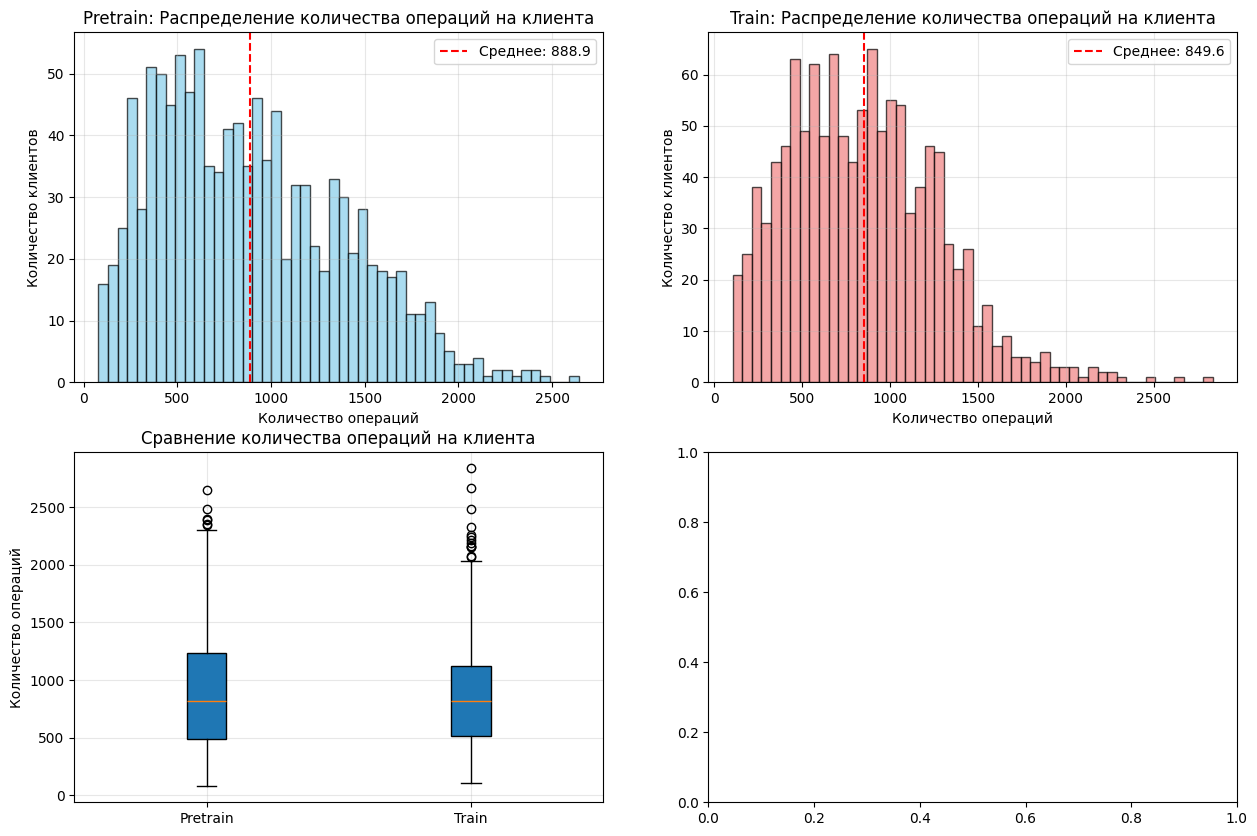

In [ ]:
# Анализ количества операций по клиентам
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Распределение количества операций на клиента (pretrain)
pretrain_ops_per_customer = pretrain_df.groupby('customer_id').size()
axes[0, 0].hist(pretrain_ops_per_customer, bins=50, edgecolor='black', alpha=0.7, color='skyblue')
axes[0, 0].set_xlabel('Количество операций')
axes[0, 0].set_ylabel('Количество клиентов')
axes[0, 0].set_title('Pretrain: Распределение количества операций на клиента')
axes[0, 0].axvline(pretrain_ops_per_customer.mean(), color='red', linestyle='--',
                    label=f'Среднее: {pretrain_ops_per_customer.mean():.1f}')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# 2. Распределение количества операций на клиента (train)
train_ops_per_customer = train_df.groupby('customer_id').size()
axes[0, 1].hist(train_ops_per_customer, bins=50, edgecolor='black', alpha=0.7, color='lightcoral')
axes[0, 1].set_xlabel('Количество операций')
axes[0, 1].set_ylabel('Количество клиентов')
axes[0, 1].set_title('Train: Распределение количества операций на клиента')
axes[0, 1].axvline(train_ops_per_customer.mean(), color='red', linestyle='--',
                    label=f'Среднее: {train_ops_per_customer.mean():.1f}')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# 3. Boxplot сравнение
axes[1, 0].boxplot([pretrain_ops_per_customer, train_ops_per_customer],
                    labels=['Pretrain', 'Train'], patch_artist=True)
axes[1, 0].set_ylabel('Количество операций')
axes[1, 0].set_title('Сравнение количества операций на клиента')
axes[1, 0].grid(alpha=0.3)

# Статистика
print(f"\nPretrain:")
print(f"Всего клиентов: {len(pretrain_ops_per_customer):,}")
print(f"Среднее количество операций: {pretrain_ops_per_customer.mean():.2f}")
print(f"Медиана: {pretrain_ops_per_customer.median():.0f}")
print(f"Минимум: {pretrain_ops_per_customer.min()}")
print(f"Максимум: {pretrain_ops_per_customer.max()}")
print(f"Стандартное отклонение: {pretrain_ops_per_customer.std():.2f}")

print(f"\nTrain:")
print(f"Всего клиентов: {len(train_ops_per_customer):,}")
print(f"Среднее количество операций: {train_ops_per_customer.mean():.2f}")
print(f"Медиана: {train_ops_per_customer.median():.0f}")
print(f"Минимум: {train_ops_per_customer.min()}")
print(f"Максимум: {train_ops_per_customer.max()}")
print(f"Стандартное отклонение: {train_ops_per_customer.std():.2f}")

# Распределение по квантилям
print(f"Распределение по квантилям:")
quantiles = train_ops_per_customer.quantile([0.25, 0.5, 0.75, 0.9, 0.95, 0.99])
for q, val in quantiles.items():
    print(f"{int(q*100)}% клиентов имеют ≤ {val:.0f} операций")

# Catboost

## Data processing


In [ ]:
def compute_cumulative_features(df: pl.DataFrame) -> pl.DataFrame:
    """
    Вычисление кумулятивных признаков для DataFrame.
    Включает фичи из чужого кода и расширенные фичи для fraud detection.
    """
    import math

    df = df.sort(["customer_id", "event_dttm"])

    # ========== Существующие кумулятивные фичи ==========
    df = df.with_columns(
        pl.col("event_dttm").rank("ordinal").over("customer_id").sub(1).alias("txn_sequence")
    )

    df = df.with_columns(
        pl.col("txn_sequence").alias("cum_count")
    )

    df = df.with_columns([
        pl.col("operaton_amt")
        .shift(1)
        .fill_null(0.0)
        .cum_sum()
        .over("customer_id")
        .alias("cum_sum")
    ])

    df = df.with_columns(
        (pl.col("cum_sum") / (pl.col("cum_count") + 1)).alias("cum_avg")
    )

    df = df.with_columns(
        (pl.col("operaton_amt") - pl.col("cum_avg")).alias("amount_diff_from_cum_avg")
    )

    df = df.with_columns(
        (pl.col("cum_count") == 0).alias("is_first_txn")
    )

    df = df.with_columns(
        pl.col("cum_avg").fill_null(0.0)
    )

    # ========== Фичи из чужого кода ==========
    # 1. prev_amt - предыдущая сумма операции
    df = df.with_columns(
        pl.col("operaton_amt")
        .shift(1)
        .over("customer_id")
        .fill_null(-1.0)
        .alias("prev_amt")
    )

    # 2. ops_7d, ops_14d, ops_21d - количество операций за последние N дней
    df = df.with_columns(
        pl.col("event_dttm")
        .rank("ordinal")
        .over("customer_id")
        .alias("txn_rank")
    )

    # ops_7d
    df = df.with_columns(
        pl.col("txn_rank")
        .sub(pl.col("txn_rank").shift(6).over("customer_id"))
        .fill_null(0)
        .add(1)
        .clip(upper_bound=7)
        .alias("ops_7d")
    )

    # ops_14d
    df = df.with_columns(
        pl.col("txn_rank")
        .sub(pl.col("txn_rank").shift(13).over("customer_id"))
        .fill_null(0)
        .add(1)
        .clip(upper_bound=14)
        .alias("ops_14d")
    )

    # ops_21d
    df = df.with_columns(
        pl.col("txn_rank")
        .sub(pl.col("txn_rank").shift(20).over("customer_id"))
        .fill_null(0)
        .add(1)
        .clip(upper_bound=21)
        .alias("ops_21d")
    )

    # 3. avg_amt_7d, avg_amt_14d, avg_amt_21d - средняя сумма за N дней
    df = df.with_columns(
        pl.col("operaton_amt")
        .shift(1)
        .rolling_mean(7, min_samples=1)
        .over("customer_id")
        .fill_null(0.0)
        .alias("avg_amt_7d_raw")
    )

    df = df.with_columns(
        (pl.col("avg_amt_7d_raw") - pl.col("operaton_amt"))
        .fill_null(0.0)
        .alias("avg_amt_7d")
    )

    df = df.with_columns(
        pl.col("operaton_amt")
        .shift(1)
        .rolling_mean(14, min_samples=1)
        .over("customer_id")
        .fill_null(0.0)
        .alias("avg_amt_14d_raw")
    )

    df = df.with_columns(
        (pl.col("avg_amt_14d_raw") - pl.col("operaton_amt"))
        .fill_null(0.0)
        .alias("avg_amt_14d")
    )

    df = df.with_columns(
        pl.col("operaton_amt")
        .shift(1)
        .rolling_mean(21, min_samples=1)
        .over("customer_id")
        .fill_null(0.0)
        .alias("avg_amt_21d_raw")
    )

    df = df.with_columns(
        (pl.col("avg_amt_21d_raw") - pl.col("operaton_amt"))
        .fill_null(0.0)
        .alias("avg_amt_21d")
    )

    # 4. is_first_op - первая операция у клиента
    df = df.with_columns(
        (pl.col("txn_rank") == 1).alias("is_first_op")
    )

    # ========== Lockstep-поведение ==========
    # 5. same_amount_count - количество операций с такой же суммой в истории клиента
    df = df.with_columns(
        pl.col("operaton_amt")
        .rank("dense")
        .over(["customer_id", "operaton_amt"])
        .alias("same_amount_count")
    )

    # 6. time_since_last_same_mcc - время с последней операции с таким же MCC
    if "mcc_code" in df.columns:
        df = df.with_columns(
            pl.col("event_dttm")
            .diff()
            .over(["customer_id", "mcc_code"])
            .dt.total_seconds()
            .fill_null(-1)
            .alias("time_since_last_same_mcc")
        )

    # ========== Device Intelligence ==========
    # 7. device_risk_score - композитный признак рискованности устройства (ИСПРАВЛЕНО: проверка типов)
    if all(col in df.columns for col in ["compromised", "web_rdp_connection", "phone_voip_call_state"]):
        # Убеждаемся что колонки числовые
        df = df.with_columns([
            pl.col("compromised").cast(pl.Int64).fill_null(0).alias("compromised"),
            pl.col("web_rdp_connection").cast(pl.Int64).fill_null(0).alias("web_rdp_connection"),
            pl.col("phone_voip_call_state").cast(pl.Int64).fill_null(0).alias("phone_voip_call_state")
        ])

        df = df.with_columns(
            (pl.col("compromised") * 3 +
             pl.col("web_rdp_connection") * 2 +
             pl.col("phone_voip_call_state") * 1)
            .alias("device_risk_score")
        )

    # 8. timezone_change - смена временной зоны
    if "timezone" in df.columns:
        df = df.with_columns(
            (pl.col("timezone") != pl.col("timezone").shift(1).over("customer_id"))
            .fill_null(False)
            .alias("timezone_changed")
        )

    # 9. browser_language_changes - количество смен языка браузера
    if "browser_language" in df.columns:
        # Shifted value for the previous event per customer
        df = df.with_columns(
            pl.col("browser_language")
            .shift(1)
            .over("customer_id")
            .alias("_browser_language_prev")
        )

        df = df.with_columns(
            (pl.col("browser_language") != pl.col("_browser_language_prev"))
            .cast(pl.Int64)
            .fill_null(0)
            .cum_sum()
            .over("customer_id")
            .alias("browser_language_changes")
        )

        df = df.drop("_browser_language_prev")

    # ========== Временные паттерны ==========
    # 10. hour_of_day - час дня
    df = df.with_columns(
        pl.col("event_dttm").dt.hour().alias("hour_of_day")
    )

    # 11. is_night - ночная операция (23:00-06:00)
    df = df.with_columns(
        ((pl.col("hour_of_day") >= 23) | (pl.col("hour_of_day") <= 6))
        .alias("is_night")
    )

    # 12. night_ops_ratio - доля ночных операций в истории клиента
    df = df.with_columns(
        pl.col("is_night")
        .cast(pl.Int64)
        .cum_sum()
        .over("customer_id")
        .alias("night_ops_count")
    )

    df = df.with_columns(
        (pl.col("night_ops_count") / (pl.col("cum_count") + 1))
        .alias("night_ops_ratio")
    )

    # 13. is_night_for_client - ночная операция для клиента с низкой долей ночных операций
    df = df.with_columns(
        (pl.col("is_night") & (pl.col("night_ops_ratio") < 0.1))
        .alias("is_night_for_client")
    )

    # 14. hour_drift - дрейф среднего времени операции
    df = df.with_columns(
        pl.col("hour_of_day")
        .rolling_mean(10, min_samples=1)
        .over("customer_id")
        .alias("hour_drift")
    )

    # 15. time_diff - интервал между операциями в секундах
    df = df.with_columns(
        pl.col("event_dttm")
        .diff()
        .over("customer_id")
        .dt.total_seconds()
        .fill_null(0)
        .alias("time_diff_seconds")
    )

    # 16. irregularity_index - коэффициент вариации интервалов
    df = df.with_columns(
        pl.col("time_diff_seconds")
        .rolling_std(10, min_samples=1)
        .over("customer_id")
        .alias("time_diff_std")
    )

    df = df.with_columns(
        pl.col("time_diff_seconds")
        .rolling_mean(10, min_samples=1)
        .over("customer_id")
        .alias("time_diff_mean")
    )

    df = df.with_columns(
        (pl.col("time_diff_std") / (pl.col("time_diff_mean") + 1))
        .fill_null(0)
        .alias("irregularity_index")
    )

    # ========== Session-based фичи ==========
    # 17. session_freq - частота использования сессии (сколько раз встречалась локально)
    if "session_id" in df.columns:
        df = df.with_columns([
            pl.col('session_id').count().over('session_id').alias('session_freq')
        ])

    # 18. ops_in_session_so_far - сколько операций уже было в этой сессии
    if "session_id" in df.columns:
        df = df.with_columns([
            pl.col('event_dttm').rank('ordinal').over('session_id').sub(1).alias('ops_in_session_so_far'),
            (pl.col('event_dttm').rank('ordinal').over('session_id') == 1).alias('is_first_in_session')
        ])

    # 19. session_total_amount - общая сумма в сессии (кумулятивная)
    if "session_id" in df.columns and "operaton_amt" in df.columns:
        df = df.with_columns([
            pl.col('operaton_amt').cum_sum().over('session_id').alias('session_total_amount')
        ])

    # 20. time_from_prev_in_session - время с предыдущей операции в сессии
    if "session_id" in df.columns:
        df = df.with_columns([
            pl.col('event_dttm')
            .diff()
            .over('session_id')
            .dt.total_seconds()
            .fill_null(-1)
            .alias('time_from_prev_in_session')
        ])

    # ========== Удаляем временные колонки ==========
    cols_to_drop = ["txn_rank", "avg_amt_7d_raw", "avg_amt_14d_raw", "avg_amt_21d_raw",
                    "night_ops_count", "time_diff_std", "time_diff_mean"]
    df = df.drop([col for col in cols_to_drop if col in df.columns])

    return df

In [ ]:
def basic_preprocessing(df: pl.LazyFrame) -> pl.LazyFrame:
    """
    Универсальная предобработка:
    - парсинг даты
    - временные признаки
    - флаги пропусков + заполнение для всех ключевых колонок
    - логарифм суммы
    - приведение типов для консистентности
    """
    schema = df.collect_schema()
    columns = schema.names()

    # Дата и время
    if "event_dttm" in columns:
        # Проверяем тип колонки - если строка, преобразуем в datetime
        event_dttm_dtype = schema["event_dttm"]
        if event_dttm_dtype == pl.Utf8:
            df = df.with_columns(
                pl.col("event_dttm").str.strptime(pl.Datetime, format="%Y-%m-%d %H:%M:%S").alias("event_dttm")
            )

        # Извлекаем временные признаки
        df = df.with_columns([
            pl.col("event_dttm").dt.hour().alias("hour"),
            pl.col("event_dttm").dt.weekday().alias("weekday"),
            pl.col("event_dttm").dt.day().alias("day_of_month"),
            pl.col("event_dttm").dt.month().alias("month"),
            pl.col("event_dttm").dt.ordinal_day().alias("day_of_year"),
        ])

    # ---------- operaton_amt ----------
    if "operaton_amt" in columns:
        df = df.with_columns([
            pl.col("operaton_amt").is_null().alias("operaton_amt_missing"),
            pl.col("operaton_amt").fill_null(0.0).alias("operaton_amt"),
        ])
        df = df.with_columns(
            pl.col("operaton_amt").log1p().alias("log_operaton_amt")
        )

    # ---------- currency_iso_cd ----------
    if "currency_iso_cd" in columns:
        df = df.with_columns([
            pl.col("currency_iso_cd").is_null().alias("currency_missing"),
            pl.col("currency_iso_cd").fill_null(-1).cast(pl.Int64).alias("currency_iso_cd"),
        ])

    # ---------- mcc_code ----------
    if "mcc_code" in columns:
        df = df.with_columns([
            pl.col("mcc_code").is_null().alias("mcc_missing"),
            pl.col("mcc_code").cast(pl.String).fill_null("-1").cast(pl.Int64).alias("mcc_code"),
        ])

    # ---------- pos_cd ----------
    if "pos_cd" in columns:
        df = df.with_columns([
            pl.col("pos_cd").is_null().alias("pos_missing"),
            pl.col("pos_cd").fill_null(-1).cast(pl.Int64).alias("pos_cd"),
        ])

    # ---------- accept_language ----------
    if "accept_language" in columns:
        df = df.with_columns([
            pl.col("accept_language").is_null().alias("accept_language_missing"),
            pl.col("accept_language").fill_null("unknown").alias("accept_language"),
        ])

    # ---------- browser_language ----------
    if "browser_language" in columns:
        df = df.with_columns([
            pl.col("browser_language").is_null().alias("browser_language_missing"),
            pl.col("browser_language")
              .fill_null("unknown")
              .str.replace_all("not available", "unknown")
              .alias("browser_language")
        ])

    # ---------- timezone ----------
    if "timezone" in columns:
        df = df.with_columns([
            pl.col("timezone").is_null().alias("timezone_missing"),
            pl.col("timezone").fill_null(-1).cast(pl.Int64).alias("timezone"),
        ])

    # ---------- battery ----------
    if "battery" in columns:
        df = df.with_columns([
            pl.col("battery").is_null().alias("battery_missing"),
            pl.when(
                # Сначала обрабатываем специальные строки
                pl.col("battery").is_null() |
                (pl.col("battery") == "not available") |
                (pl.col("battery") == "NaN")
            )
            .then(pl.lit(-1))
            .otherwise(
                # Для остальных пытаемся извлечь цифры
                pl.col("battery")
                  .str.extract(r"(\d+)")
                  .cast(pl.Int64)
            )
            .alias("battery")
        ])

    if "device_system_version" in columns:
        df = df.with_columns([
            pl.col("device_system_version").is_null().alias("device_system_version_missing"),
            pl.col("device_system_version")
              .fill_null("unknown")
              .str.replace_all("not available", "unknown")
              .cast(pl.String)
              .alias("device_system_version")
        ])

    if "screen_size" in columns:
      df = df.with_columns([
          pl.col("screen_size").is_null().alias("screen_size_missing"),
          pl.col("screen_size")
            .fill_null("unknown")
            .str.replace_all("not available", "unknown")
            .cast(pl.String)
            .alias("screen_size")
      ])

    # ---------- Другие колонки ----------
    optional_cols = [
        "session_id", "operating_system_type",
        "developer_tools", "phone_voip_call_state",
        "web_rdp_connection", "compromised"
    ]
    for col in optional_cols:
        if col in columns:
            dtype = schema[col]

            # Для числовых колонок
            if dtype in (pl.Int64, pl.Float64, pl.Int32, pl.Float32, pl.UInt32, pl.UInt64):
                fill_val = 0
                df = df.with_columns(pl.col(col).cast(pl.Int64))
            else:
                # Для строковых - пытаемся привести к Int64
                fill_val = 0
                df = df.with_columns(
                    pl.col(col).cast(pl.String).fill_null("0").cast(pl.Int64).alias(col)
                )

            df = df.with_columns([
                pl.col(col).is_null().alias(f"{col}_missing"),
                pl.col(col).fill_null(fill_val).alias(col),
            ])

    # ФИНАЛЬНОЕ ПРИВЕДЕНИЕ ТИПОВ
    id_cols = ["customer_id", "event_id", "session_id", "event_type_nm", "event_desc",
               "channel_indicator_type", "channel_indicator_sub_type", "currency_iso_cd",
               "mcc_code", "pos_cd", "timezone", "operating_system_type",
               "phone_voip_call_state", "web_rdp_connection", "compromised"]

    schema_cols = df.collect_schema().names()
    for col in id_cols:
        if col in schema_cols:
            df = df.with_columns(pl.col(col).cast(pl.Int64))

    return df

In [ ]:
def log_dataset_info(df: pl.DataFrame, name: str):
    """Логгирование информации о датасете в MLFlow."""
    mlflow.log_param(f"{name}_n_rows", len(df))
    mlflow.log_param(f"{name}_n_columns", len(df.columns))

    if "target" in df.columns:
        target_counts = df["target"].value_counts()
        mlflow.log_metric(f"{name}_target_0_count", target_counts.filter(pl.col("target") == 0)["count"].item())
        mlflow.log_metric(f"{name}_target_1_count", target_counts.filter(pl.col("target") == 1)["count"].item())

    print(f"{name}: {len(df)} rows, {len(df.columns)} columns")

def compute_global_features(df: pl.DataFrame) -> pl.DataFrame:
    """
    Вычисление глобальных признаков для всего датасета.
    """
    # Общее количество транзакций
    df = df.with_columns(pl.lit(df.height).alias("global_total_transactions"))

    # Уникальные клиенты
    df = df.with_columns(pl.lit(df["customer_id"].n_unique()).alias("global_unique_customers"))

    # Уникальные MCC-коды
    if "mcc_code" in df.columns:
        df = df.with_columns(pl.lit(df["mcc_code"].n_unique()).alias("global_unique_mcc"))

    # Уникальные типы операций
    if "event_type_nm" in df.columns:
        df = df.with_columns(pl.lit(df["event_type_nm"].n_unique()).alias("global_unique_event_types"))

    # Глобальное среднее суммы операции
    if "operaton_amt" in df.columns:
        global_mean_amt = df["operaton_amt"].mean()
        df = df.with_columns(pl.lit(global_mean_amt).alias("global_mean_operaton_amt"))

    # Глобальное стандартное отклонение суммы операции
    if "operaton_amt" in df.columns:
        global_std_amt = df["operaton_amt"].std()
        df = df.with_columns(pl.lit(global_std_amt).alias("global_std_operaton_amt"))

    return df

def prepare_data(
    pretrain_path: str,
    main_path: str,
    target_path: str = None,
    val_weeks: int = 4,
    temp_dir: str = None,
    is_train: bool = True,
    batch_size: int = 5000
):
    """
    Универсальная функция подготовки данных с MLFlow логгированием.
    Оптимизирована для работы с ограниченной памятью.
    """
    import tempfile
    import gc

    def cast_to_common_types(df: pl.DataFrame) -> pl.DataFrame:
        """Приведение типов к единому формату."""
        cast_exprs = []
        for col in df.columns:
            dtype = df.schema[col]
            if dtype in (pl.Int8, pl.Int16, pl.Int32):
                cast_exprs.append(pl.col(col).cast(pl.Int64).alias(col))
            elif dtype in (pl.UInt8, pl.UInt16, pl.UInt32, pl.UInt64):
                cast_exprs.append(pl.col(col).cast(pl.Int64).alias(col))
            elif dtype in (pl.Float32,):
                cast_exprs.append(pl.col(col).cast(pl.Float64).alias(col))
        if cast_exprs:
            df = df.with_columns(cast_exprs)
        return df

    if temp_dir is None:
        temp_dir = tempfile.mkdtemp()
    else:
        os.makedirs(temp_dir, exist_ok=True)

    # ========== Загрузка pretrain ==========
    print("Загрузка pretrain данных...")
    if os.path.isdir(pretrain_path):
        pretrain_files = [os.path.join(pretrain_path, f) for f in os.listdir(pretrain_path) if f.endswith('.parquet')]
        pretrain_dfs = [pl.read_parquet(f) for f in tqdm(pretrain_files, desc="Reading pretrain")]
        pretrain_df = pl.concat(pretrain_dfs)
        del pretrain_dfs
        gc.collect()
    else:
        pretrain_df = pl.read_parquet(pretrain_path)

    pretrain_df = cast_to_common_types(pretrain_df)
    print(f"Pretrain shape: {pretrain_df.shape}")
    mlflow.log_param("pretrain_shape", str(pretrain_df.shape))

    # Предобработка pretrain
    print("Предобработка pretrain...")
    pretrain_df = basic_preprocessing(pretrain_df.lazy()).collect()
    pretrain_df = pretrain_df.sort(["customer_id", "event_dttm"])
    print(f"Pretrain после preprocessing: {pretrain_df.shape}")
    gc.collect()

    # ========== Загрузка основных данных ==========
    print("\nЗагрузка основных данных...")
    if os.path.isdir(main_path):
        main_files = [os.path.join(main_path, f) for f in os.listdir(main_path) if f.endswith('.parquet')]
        main_files.sort()
    else:
        main_files = [main_path]

    print(f"Найдено файлов: {len(main_files)}")
    mlflow.log_param("n_main_files", len(main_files))

    # ========== Обработка в батчах ==========
    print("\nОбработка данных в батчах...")
    original_event_ids = []

    for file_idx, file_path in enumerate(tqdm(main_files, desc="Processing files")):
        print(f"\n--- Файл {file_idx + 1}/{len(main_files)}: {os.path.basename(file_path)} ---")

        df = pl.read_parquet(file_path)
        print(f"Загружено строк: {len(df)}")
        original_event_ids.extend(df["event_id"].to_list())

        df = cast_to_common_types(df)

        # ВАЖНО: Применяем basic_preprocessing к текущему файлу ПЕРЕД concat
        print("Basic preprocessing текущего файла...")
        df = basic_preprocessing(df.lazy()).collect()
        print(f"После preprocessing: {df.shape}")

        # ОПТИМИЗАЦИЯ: Фильтруем pretrain только для текущих клиентов
        print("Фильтрация pretrain...")
        current_customers = df["customer_id"].unique().to_list()
        pretrain_filtered = pretrain_df.filter(pl.col("customer_id").is_in(current_customers))
        print(f"Pretrain отфильтрован: {len(pretrain_filtered)} строк")

        # Теперь оба DataFrame имеют одинаковое количество колонок
        print(f"Pretrain shape: {pretrain_filtered.shape}, Current file shape: {df.shape}")

        # Объединяем
        df_combined = pl.concat([pretrain_filtered, df])
        del pretrain_filtered
        gc.collect()

        # Cumulative features (basic_preprocessing уже применен)
        print("Computing cumulative features...")
        df_combined = compute_cumulative_features(df_combined)

        # Оставляем только текущий файл
        event_ids_list = df["event_id"].unique().to_list()
        df_processed = df_combined.filter(pl.col("event_id").is_in(event_ids_list))

        # Сохраняем на диск
        batch_path = os.path.join(temp_dir, f"batch_{file_idx}.parquet")
        df_processed.write_parquet(batch_path)
        print(f"Батч сохранен: {batch_path}")

        del df_combined, df_processed, df
        gc.collect()

    # ========== Объединяем батчи с диска ==========
    print("\nОбъединение батчей с диска...")
    batch_files = [os.path.join(temp_dir, f"batch_{i}.parquet") for i in range(len(main_files))]

    df_final = None
    for batch_file in tqdm(batch_files, desc="Loading batches"):
        batch_df = pl.read_parquet(batch_file)
        if df_final is None:
            df_final = batch_df
        else:
            df_final = pl.concat([df_final, batch_df])
        del batch_df
        gc.collect()

    print(f"Итого строк: {len(df_final)}")

    # ========== Глобальные фичи ==========
    print("\nВычисление глобальных фич...")
    df_final = compute_global_features(df_final)

    # Пересчет сессионных признаков на полном датасете (для коррекции батчевого рассчета)
    if "session_id" in df_final.columns:
        df_final = df_final.with_columns([
            pl.col('session_id').count().over('session_id').alias('session_freq'),
            pl.col('event_dttm').rank('ordinal').over('session_id').sub(1).alias('ops_in_session_so_far'),
            (pl.col('event_dttm').rank('ordinal').over('session_id') == 1).cast(pl.Int64).alias('is_first_in_session'),
            pl.col('operaton_amt').cum_sum().over('session_id').alias('session_total_amount'),
            pl.col('event_dttm').diff().over('session_id').dt.total_seconds().fill_null(-1).alias('time_from_prev_in_session')
        ])

    print(f"Финальный shape: {df_final.shape}")
    gc.collect()

    # ========== Добавление target ==========
    if is_train and target_path:
        print("\nДобавление target...")
        target_df = pl.read_parquet(target_path)
        print(f"Target shape: {target_df.shape}")
        print(f"Target columns: {target_df.columns}")

        # Проверяем колонки для join
        if 'customer_id' in target_df.columns:
            # Join по customer_id и event_id (inner, чтобы убрать строки без target)
            df_final = df_final.unique(subset=["event_id"], keep="first")
            df_final = df_final.join(target_df, on=["customer_id", "event_id"], how="inner")
        else:
            # Join только по event_id (inner)
            df_final = df_final.unique(subset=["event_id"], keep="first")
            df_final = df_final.join(target_df, on="event_id", how="inner")

        print(f"После join с target: {len(df_final)}")
        print(f"Target distribution: {df_final['target'].value_counts()}")
        del target_df
        gc.collect()

    # ========== Определение признаков ==========
    exclude_cols = {"event_id", "customer_id", "event_dttm", "target", "session_id"}
    features = [col for col in df_final.columns if col not in exclude_cols]

    print(f"\nКоличество признаков: {len(features)}")
    mlflow.log_param("n_features", len(features))
    mlflow.log_param("features", ",".join(features[:50]))

    # ========== Разделение на train/val ==========
    if is_train:
        print("\nРазделение на train/val...")
        max_date = df_final["event_dttm"].max()
        split_date = max_date - timedelta(weeks=val_weeks)

        print(f"Max date: {max_date}, Split date: {split_date}")

        train_df = df_final.filter(pl.col("event_dttm") < split_date)
        val_df = df_final.filter(pl.col("event_dttm") >= split_date)

        print(f"Train shape: {train_df.shape}, Val shape: {val_df.shape}")

        mlflow.log_param("split_date", str(split_date))
        mlflow.log_metric("train_rows", len(train_df))
        mlflow.log_metric("val_rows", len(val_df))

        if "target" in train_df.columns:
            train_target_dist = train_df["target"].value_counts()
            val_target_dist = val_df["target"].value_counts()
            mlflow.log_metric("train_target_0", train_target_dist.filter(pl.col("target") == 0)["count"].item())
            mlflow.log_metric("train_target_1", train_target_dist.filter(pl.col("target") == 1)["count"].item())
            mlflow.log_metric("val_target_0", val_target_dist.filter(pl.col("target") == 0)["count"].item())
            mlflow.log_metric("val_target_1", val_target_dist.filter(pl.col("target") == 1)["count"].item())

        del df_final
        gc.collect()
        return train_df, val_df, features
    else:
        print("\nПодготовка test завершена")
        return df_final, original_event_ids

In [ ]:
import gc
gc.collect()

537

In [ ]:
# Запуск MLFlow run
with mlflow.start_run(run_name="data_preparation"):
    print("=== Подготовка train данных ===")

    train_df, val_df, features = prepare_data(
        pretrain_path=os.path.join(DATA_PATH, "pretrain"),
        main_path=os.path.join(DATA_PATH, "train"),
        target_path=os.path.join(DATA_PATH, "train_labels.parquet"),
        val_weeks=4,
        temp_dir=os.path.join(DRIVE_PATH, "temp_processing"),
        is_train=True,
        batch_size=5000
    )

    print(f"\nTrain shape: {train_df.shape}")
    print(f"Val shape: {val_df.shape}")
    print(f"Features count: {len(features)}")

=== Подготовка train данных ===
Загрузка pretrain данных...


Reading pretrain: 100%|██████████| 3/3 [00:43<00:00, 14.59s/it]


Pretrain shape: (90939957, 23)
Предобработка pretrain...
Pretrain после preprocessing: (90939957, 45)

Загрузка основных данных...
Найдено файлов: 3

Обработка данных в батчах...


Processing files:   0%|          | 0/3 [00:00<?, ?it/s]


--- Файл 1/3: train_part_1.parquet ---
Загружено строк: 28618594
Basic preprocessing текущего файла...
После preprocessing: (28618594, 45)
Фильтрация pretrain...
Pretrain отфильтрован: 30329960 строк
Pretrain shape: (30329960, 45), Current file shape: (28618594, 45)
Computing cumulative features...


...

Батч сохранен: ./gdrive/MyDrive/antifrod/temp_processing/batch_1.parquet

--- Файл 3/3: train_part_3.parquet ---
Загружено строк: 28500849
Basic preprocessing текущего файла...
После preprocessing: (28500849, 45)
Фильтрация pretrain...
Pretrain отфильтрован: 30372137 строк
Pretrain shape: (30372137, 45), Current file shape: (28500849, 45)
Computing cumulative features...


Processing files: 100%|██████████| 3/3 [04:30<00:00, 90.33s/it]


Батч сохранен: ./gdrive/MyDrive/antifrod/temp_processing/batch_2.parquet

Объединение батчей с диска...


Loading batches: 100%|██████████| 3/3 [00:09<00:00,  3.07s/it]


Итого строк: 85677840

Вычисление глобальных фич...
Финальный shape: (85677840, 82)

Добавление target...
Target shape: (87514, 3)
Target columns: ['customer_id', 'event_id', 'target']
После join с target: 87514
Target distribution: shape: (2, 2)
┌────────┬───────┐
│ target ┆ count │
│ ---    ┆ ---   │
│ i32    ┆ u32   │
╞════════╪═══════╡
│ 1      ┆ 51438 │
│ 0      ┆ 36076 │
└────────┴───────┘

Количество признаков: 78

Разделение на train/val...
Max date: 2025-05-31 23:55:33, Split date: 2025-05-03 23:55:33
Train shape: (74992, 83), Val shape: (12522, 83)

Train shape: (74992, 83)
Val shape: (12522, 83)
Features count: 78


In [ ]:
# Сохраняем для последующего использования
train_df.write_parquet(os.path.join(DATA_PATH, "train_processed.parquet"))
val_df.write_parquet(os.path.join(DATA_PATH, "val_processed.parquet"))

## Data load

In [ ]:
train_df = pl.read_parquet(os.path.join(DATA_PATH, "train_processed.parquet"))
train_df

customer_id,event_id,event_dttm,event_type_nm,event_desc,channel_indicator_type,channel_indicator_sub_type,operaton_amt,currency_iso_cd,mcc_code,pos_cd,accept_language,browser_language,timezone,session_id,operating_system_type,battery,device_system_version,screen_size,developer_tools,phone_voip_call_state,web_rdp_connection,compromised,hour,weekday,day_of_month,month,day_of_year,operaton_amt_missing,log_operaton_amt,currency_missing,mcc_missing,pos_missing,accept_language_missing,browser_language_missing,timezone_missing,battery_missing,…,cum_count,cum_sum,cum_avg,amount_diff_from_cum_avg,is_first_txn,prev_amt,ops_7d,ops_14d,ops_21d,avg_amt_7d,avg_amt_14d,avg_amt_21d,is_first_op,same_amount_count,time_since_last_same_mcc,device_risk_score,timezone_changed,browser_language_changes,hour_of_day,is_night,night_ops_ratio,is_night_for_client,hour_drift,time_diff_seconds,irregularity_index,session_freq,ops_in_session_so_far,is_first_in_session,session_total_amount,time_from_prev_in_session,global_total_transactions,global_unique_customers,global_unique_mcc,global_unique_event_types,global_mean_operaton_amt,global_std_operaton_amt,target
i64,i64,datetime[μs],i64,i64,i64,i64,f64,i64,i64,i64,str,str,i64,i64,i64,i64,str,str,i64,i64,i64,i64,i8,i8,i8,i8,i16,bool,f64,bool,bool,bool,bool,bool,bool,bool,…,u32,f64,f64,f64,bool,f64,u32,u32,u32,f64,f64,f64,bool,u32,i64,i64,bool,i64,i8,bool,f64,bool,f64,i64,f64,u32,u32,i64,f64,i64,i32,i32,i32,i32,f64,f64,i32
123355051357876,123999297638460,2025-03-17 10:55:51,7,56,4,15,0.0,-1,-1,-1,"""unknown""","""unknown""",-1,123209023573514,0,-1,"""18.3""","""393x852""",0,0,0,0,10,1,17,3,76,true,0.0,true,true,true,true,true,true,true,…,1291,1.0803e9,836131.401703,-836131.401703,false,498850.0,7,14,21,212313.714286,149636.428571,119311.190476,false,1,208,0,false,0,10,false,0.201238,false,10.2,208,1.738587,1,0,1,0.0,-1,85677840,100000,21,17,1.2473e6,1.5205e8,1
124188275014882,126344352954934,2025-04-15 08:49:38,14,75,0,5,149.0,0,16,1,"""unknown""","""unknown""",-1,0,0,-1,"""unknown""","""unknown""",0,0,0,0,8,2,15,4,105,false,5.010635,false,false,false,true,true,true,true,…,3115,3.1802e8,102061.404059,-101912.404059,false,99.0,7,14,21,459202.142857,316641.285714,241963.666667,false,1,3546,0,false,0,8,false,0.092105,false,7.4,1134,3.096783,34193349,27295401,0,2.6682e13,1134,85677840,100000,21,17,1.2473e6,1.5205e8,1
123191842602245,126490381824311,2025-01-08 18:22:06,14,73,0,5,812406.0,0,10,1,"""unknown""","""unknown""",-1,0,0,-1,"""unknown""","""unknown""",0,0,0,0,18,3,8,1,8,false,13.607757,false,false,false,true,true,true,true,…,1392,4.5644474e8,327670.308686,484735.691314,false,0.0,7,14,21,-728469.142857,-656911.857143,-675094.714286,false,1,188754,0,false,0,18,false,0.23977,false,17.0,61,2.438381,34193349,14255569,0,2.1493e12,188754,85677840,100000,21,17,1.2473e6,1.5205e8,1
123183252667813,124592003213388,2024-11-07 05:55:43,14,36,4,15,2.068437e6,0,-1,-1,"""ru""","""unknown""",-1,125528305351891,0,-1,"""unknown""","""unknown""",0,0,0,0,5,4,7,11,312,false,14.542304,false,true,true,false,true,true,true,…,1778,3.91328483e8,219971.041596,1.8485e6,false,0.0,7,14,21,-1.7225e6,-1.8781e6,-1.9310e6,false,1,51,0,false,0,5,true,0.192805,false,12.6,51,3.130756,2,0,1,2.068437e6,-1,85677840,100000,21,17,1.2473e6,1.5205e8,0
123148892928456,125339326617977,2025-02-28 09:54:08,2,88,0,5,0.0,0,10,3,"""unknown""","""unknown""",-1,0,0,-1,"""unknown""","""unknown""",0,0,0,0,9,5,28,2,59,true,0.0,false,false,false,true,true,true,true,…,2004,6.01834467e8,300166.816459,-300166.816459,false,0.0,7,14,21,8.8696e6,1.114865e7,8.6788e6,false,1,42,0,false,0,9,false,0.095761,false,8.4,42,2.961057,34193349,20791062,0,1.1013e12,42,85677840,100000,21,17,1.2473e6,1.5205e8,0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
124179685078698,124222638514642,2025-04-20 10:52:32,7,56,4,15,0.0,-1,-1,-1,"""unknown""","""unknown""",-1,126138191025544,0,-1,"

In [ ]:
val_df = pl.read_parquet(os.path.join(DATA_PATH, "val_processed.parquet"))
val_df

customer_id,event_id,event_dttm,event_type_nm,event_desc,channel_indicator_type,channel_indicator_sub_type,operaton_amt,currency_iso_cd,mcc_code,pos_cd,accept_language,browser_language,timezone,session_id,operating_system_type,battery,device_system_version,screen_size,developer_tools,phone_voip_call_state,web_rdp_connection,compromised,hour,weekday,day_of_month,month,day_of_year,operaton_amt_missing,log_operaton_amt,currency_missing,mcc_missing,pos_missing,accept_language_missing,browser_language_missing,timezone_missing,battery_missing,…,cum_count,cum_sum,cum_avg,amount_diff_from_cum_avg,is_first_txn,prev_amt,ops_7d,ops_14d,ops_21d,avg_amt_7d,avg_amt_14d,avg_amt_21d,is_first_op,same_amount_count,time_since_last_same_mcc,device_risk_score,timezone_changed,browser_language_changes,hour_of_day,is_night,night_ops_ratio,is_night_for_client,hour_drift,time_diff_seconds,irregularity_index,session_freq,ops_in_session_so_far,is_first_in_session,session_total_amount,time_from_prev_in_session,global_total_transactions,global_unique_customers,global_unique_mcc,global_unique_event_types,global_mean_operaton_amt,global_std_operaton_amt,target
i64,i64,datetime[μs],i64,i64,i64,i64,f64,i64,i64,i64,str,str,i64,i64,i64,i64,str,str,i64,i64,i64,i64,i8,i8,i8,i8,i16,bool,f64,bool,bool,bool,bool,bool,bool,bool,…,u32,f64,f64,f64,bool,f64,u32,u32,u32,f64,f64,f64,bool,u32,i64,i64,bool,i64,i8,bool,f64,bool,f64,i64,f64,u32,u32,i64,f64,i64,i32,i32,i32,i32,f64,f64,i32
124239814623881,125682927366143,2025-05-13 12:48:20,7,56,3,4,0.0,-1,-1,-1,"""unknown""","""unknown""",-1,0,0,-1,"""unknown""","""unknown""",0,0,0,0,12,2,13,5,133,true,0.0,true,true,true,true,true,true,true,…,443,2.0883e9,4.7035e6,-4.7035e6,false,0.0,7,14,21,975727.142857,1.1039e7,2.4783e7,false,1,27,0,false,0,12,false,0.074324,false,11.4,27,2.758129,34193349,31365185,0,2.8089e13,27,85677840,100000,21,17,1.2473e6,1.5205e8,0
123707238677140,125648566468202,2025-05-30 11:11:12,14,75,0,5,1.233223e6,0,17,1,"""unknown""","""unknown""",-1,0,0,-1,"""unknown""","""unknown""",0,0,0,0,11,5,30,5,150,false,14.025142,false,false,false,true,true,true,true,…,2081,5.3330e9,2.5615e6,-1.3283e6,false,164771.0,7,14,21,2.0340e7,2.0677e7,1.3440e7,false,1,60892,0,false,0,11,false,0.160423,false,12.9,18534,1.509993,34193349,33964791,0,1.4971e13,18534,85677840,100000,21,17,1.2473e6,1.5205e8,1
123956346782243,123148893237646,2025-05-18 08:04:53,14,75,0,5,218052.0,0,7,-1,"""unknown""","""unknown""",-1,0,0,-1,"""unknown""","""unknown""",0,0,0,0,8,7,18,5,138,false,12.292493,false,false,true,true,true,true,true,…,688,3.35832658e8,487420.403483,-269368.403483,false,145042.0,7,14,21,-61178.571429,-111850.142857,-145353.52381,false,1,105,0,false,0,8,false,0.04209,false,5.0,105,2.025671,34193349,32097685,0,2.1352e13,105,85677840,100000,21,17,1.2473e6,1.5205e8,1
123990706519170,125914852085526,2025-05-27 13:11:39,14,36,3,4,1.86496e6,0,-1,-1,"""ru""","""unknown""",0,124093786252531,6,-1,"""unknown""","""unknown""",0,0,1,0,13,2,27,5,147,false,14.438751,false,true,true,false,false,false,false,…,1980,1.7791e10,8.9806e6,-7.1156e6,false,0.0,7,14,21,1.3152e7,7.0108e6,6.4149e6,false,1,144,2,false,0,13,false,0.399798,false,12.3,144,2.722081,3,2,0,3.742516e6,144,85677840,100000,21,17,1.2473e6,1.5205e8,0
124239814623847,125786003592365,2025-05-11 17:05:21,14,75,0,5,49253.0,0,16,-1,"""unknown""","""unknown""",-1,0,0,-1,"""unknown""","""unknown""",0,0,0,0,17,7,11,5,131,false,10.804746,false,false,true,true,true,true,true,…,3657,1.68609505e8,46093.358393,3159.641607,false,49223.0,7,14,21,-6738.142857,-8429.0,15368.428571,false,1,259679,0,false,0,17,false,0.223346,false,11.4,259679,0.865871,34193349,31095644,0,2.8089e13,259679,85677840,100000,21,17,1.2473e6,1.5205e8,1
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
123913397109554,124720851936714,2025-05-21 16:49:47,8,86,4,15,100370.0,0,-1,-1,"""unknown""","""unknown""",-1,123698648918492,0,-

## Postprocessing

In [ ]:
cols_2_drop = ['event_dttm', 'session_id', 'event_id', 'customer_id',
               'web_rdp_connection', 'browser_language_changes',
               'global_unique_mcc', 'global_unique_event_types',
               'global_unique_customers', 'global_total_transactions',
               'ops_7d', 'developer_tools_missing', 'compromised_missing',
               'is_first_txn', 'is_first_op', 'same_amount_count',
               'ops_21d', 'ops_14d', 'browser_language']

In [ ]:
X_train = train_df.to_pandas()
y_train = train_df["target"].to_numpy().astype(int)
X_train.drop('target', axis=1, inplace=True)
X_val = val_df.to_pandas()
y_val = val_df["target"].to_numpy().astype(int)
X_val.drop('target', axis=1, inplace=True)

X_train.drop(cols_2_drop, axis=1, inplace=True)
X_val.drop(cols_2_drop, axis=1, inplace=True)

print(f"X_train shape: {X_train.shape}")

X_train shape: (74992, 63)


In [ ]:
# Определяем категориальные признаки
cat_names = [
  'event_type_nm', 'event_desc', 'channel_indicator_type',
  'channel_indicator_sub_type', 'currency_iso_cd', 'mcc_code', 'pos_cd',
  'accept_language', 'browser_language', 'timezone',
  'operating_system_type', 'battery', 'device_system_version', 'screen_size',
  'developer_tools', 'phone_voip_call_state', 'web_rdp_connection',
  'compromised', 'operaton_amt_missing', 'currency_missing', 'mcc_missing',
  'pos_missing', 'accept_language_missing', 'timezone_missing',
  'browser_language_missing', 'session_id_missing',
  'operating_system_type_missing', 'battery_missing',
  'device_system_version_missing', 'screen_size_missing',
  'developer_tools_missing', 'phone_voip_call_state_missing',
  'web_rdp_connection_missing', 'compromised_missing', 'is_first_in_session'
]

cat_features = [col for col in X_train.columns if X_train[col].dtype == 'object' or col in cat_names]
print(f"Категориальных признаков: {len(cat_features)}")

Категориальных признаков: 31


In [ ]:
# Преобразуем категориальные фичи к правильным типам даных
for col in cat_features:
  try:
    X_train[col] = X_train[col].astype(int)
    X_val[col] = X_val[col].astype(int)
  except:
      try:
        X_train[col] = X_train[col].astype(str)
        X_val[col] = X_val[col].astype(str)
      except Exception as e:
        print(f"Error while proccesing col: {e}")

In [ ]:
X_train_sample = X_train.head(50000)
y_train_sample = train_df["target"].head(50000)

# Разделяем числовые и категориальные фичи
categorical_cols = cat_features
numeric_cols = [col for col in X_train.columns if col not in categorical_cols]

print(f"Числовых фичей: {len(numeric_cols)}")
print(f"Категориальных фичей: {len(categorical_cols)}")

# Для числовых ANOVA F-value
if numeric_cols:
    f_scores, p_values = f_classif(X_train_sample[numeric_cols], y_train_sample)
    numeric_importance = pd.DataFrame({
        'feature': numeric_cols,
        'f_score': f_scores,
        'p_value': p_values,
        'type': 'numeric'
    }).sort_values('f_score', ascending=False)
    print("Топ-15 числовых фичей по F-score:")
    print(numeric_importance.head(15))

# Для категориальных label encoding + mutual information
if categorical_cols:
    cat_importance = []
    for col in categorical_cols:
        le = LabelEncoder()
        X_encoded = le.fit_transform(X_train_sample[col].astype(str))

        mi = mutual_info_classif(X_encoded.reshape(-1, 1), y_train_sample)[0]
        cat_importance.append({'feature': col, 'mutual_info': mi, 'type': 'categorical'})

    cat_importance = pd.DataFrame(cat_importance).sort_values('mutual_info', ascending=False)
    print("Топ-10 категориальных фичей по Mutual Information:")
    print(cat_importance.head(10))

Числовых фичей: 32
Категориальных фичей: 31
Топ-15 числовых фичей по F-score:
                  feature     f_score        p_value     type
5             day_of_year  952.946433  2.714336e-207  numeric
4                   month  951.766434  4.845865e-207  numeric
26           session_freq  686.257861  3.023120e-150  numeric
1                    hour  570.033601  2.784659e-125  numeric
19            hour_of_day  570.033601  2.784659e-125  numeric
23             hour_drift  448.796339   3.604095e-99  numeric
28   session_total_amount  444.925340   2.464807e-98  numeric
12               prev_amt  332.952435   3.809435e-74  numeric
25     irregularity_index  195.449071   2.492220e-44  numeric
10                cum_avg  193.511680   6.573377e-44  numeric
27  ops_in_session_so_far  137.522836   1.019846e-31  numeric
9                 cum_sum  131.845849   1.765888e-30  numeric
20               is_night  129.409814   6.005407e-30  numeric
8               cum_count  125.131447   5.156921e-29  

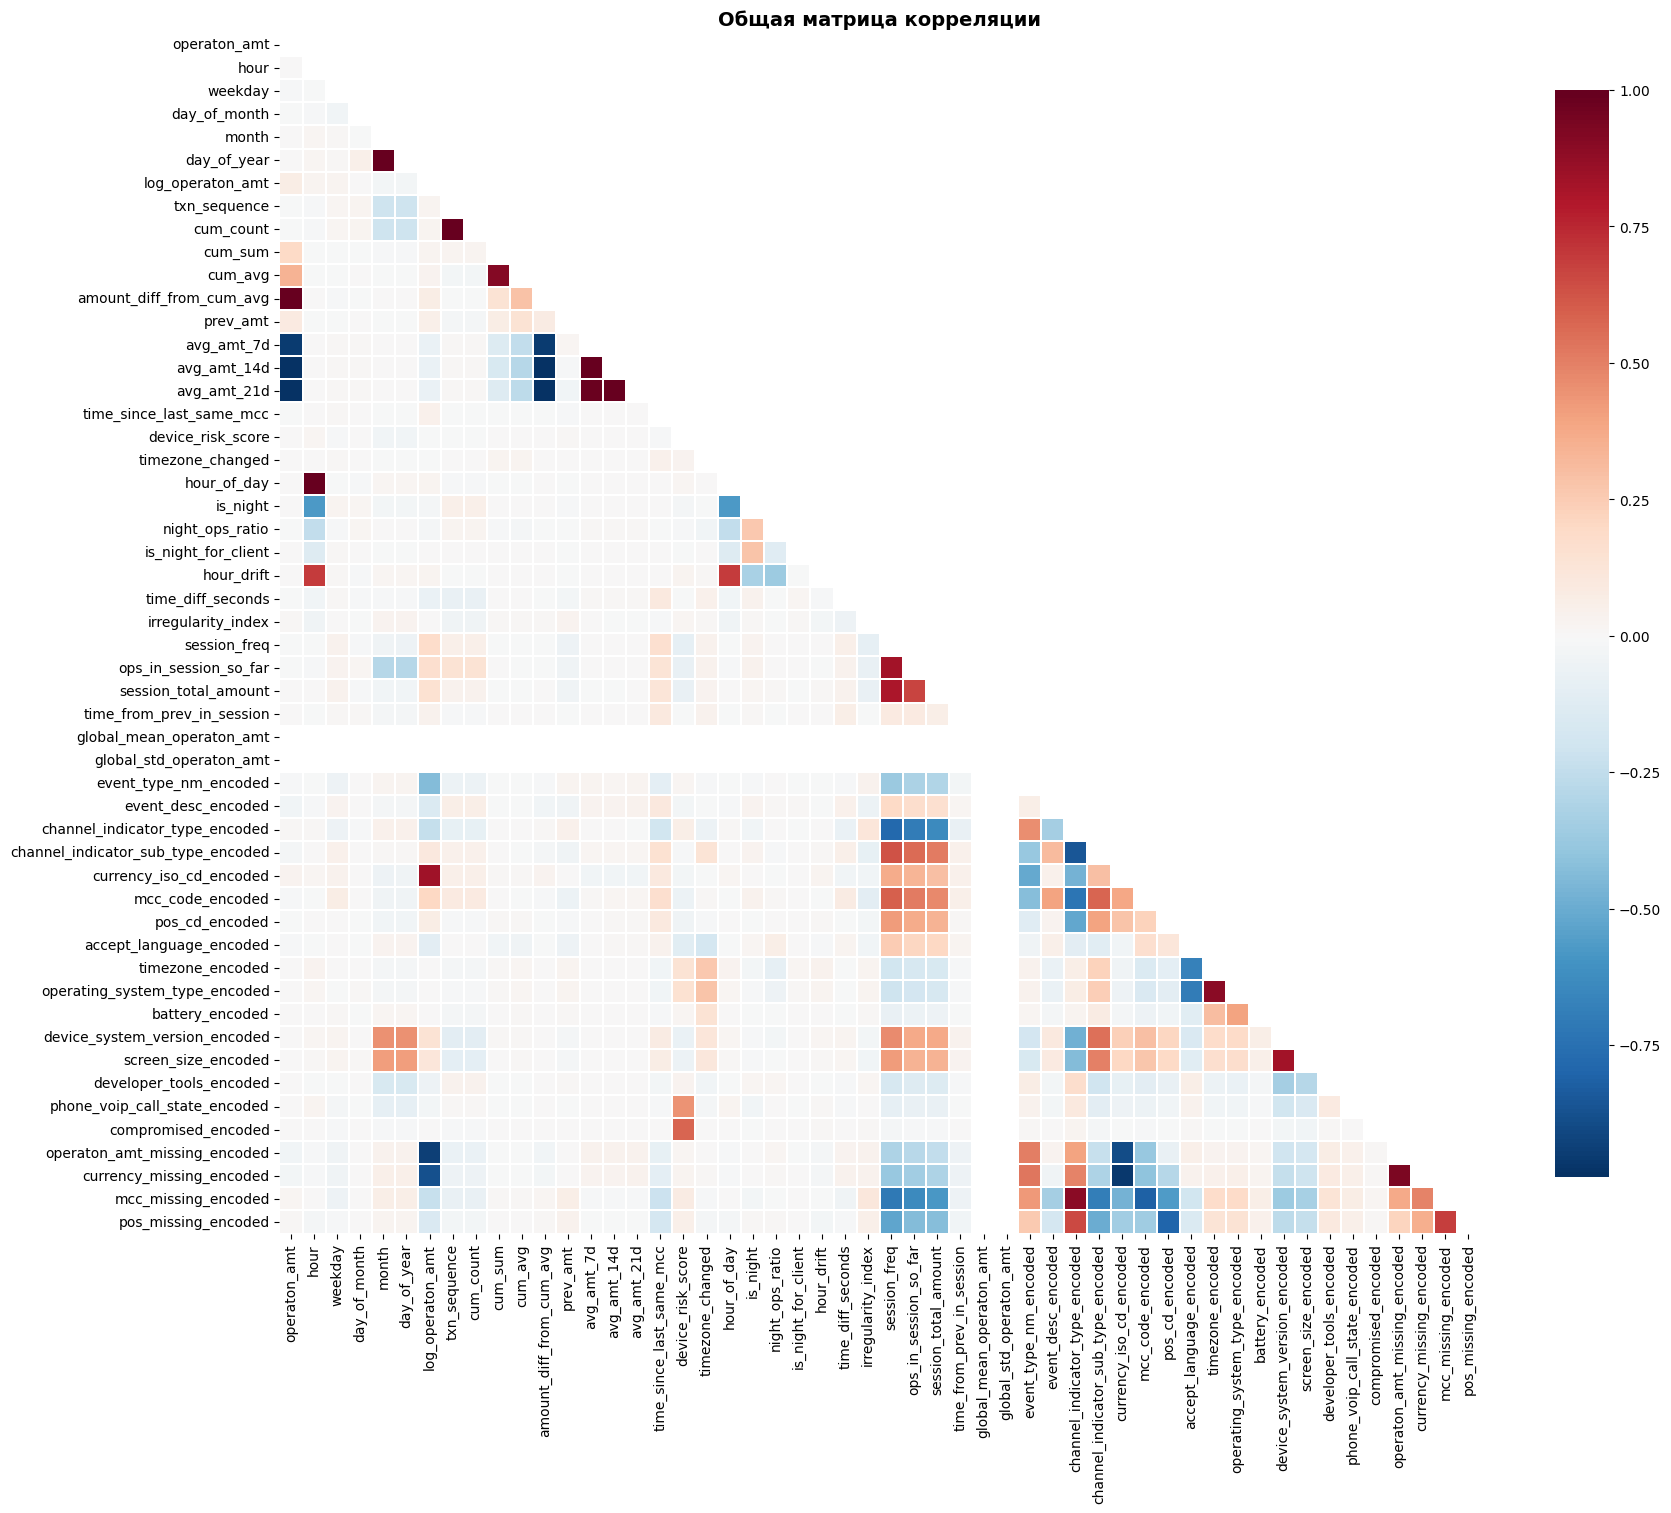

In [ ]:
top_cat_for_encoding = categorical_cols[:20]
X_combined = X_train_sample[numeric_cols].copy()

# Label encoding для категориальных
for col in top_cat_for_encoding:
    le = LabelEncoder()
    X_combined[f"{col}_encoded"] = le.fit_transform(X_train_sample[col].astype(str))

# Матрица корреляции для всех фичей
plt.figure(figsize=(18, 16))
corr_combined = X_combined.corr()

mask = np.triu(np.ones_like(corr_combined, dtype=bool))
sns.heatmap(corr_combined,
            mask=mask,
            annot=False,
            cmap='RdBu_r',
            center=0,
            square=True,
            linewidths=0.3,
            cbar_kws={"shrink": 0.8})
plt.title('Общая матрица корреляции',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
train_pool = Pool(X_train, y_train, cat_features=cat_features)
val_pool = Pool(X_val, y_val, cat_features=cat_features)

## Catboost train

In [ ]:
def objective(trial: Trial):
    params = {
        'iterations': 2000,
        'learning_rate': trial.suggest_float('learning_rate', 0.001, 0.1, log=True),
        'depth': trial.suggest_int('depth', 4, 10),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 0.1, 100.0, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bylevel': trial.suggest_float('colsample_bylevel', 0.5, 1.0),
        'border_count': trial.suggest_int('border_count', 32, 254),
        'bootstrap_type': trial.suggest_categorical('bootstrap_type', ['Bernoulli', 'MVS']),
        'loss_function': 'Logloss',
        'eval_metric': 'PRAUC',
        'random_seed': SEED,
        'early_stopping_rounds': 100,
        'verbose': 0,
        'auto_class_weights': 'Balanced',
        'task_type': 'CPU',
    }

    # Add sampling_frequency for Bernoulli bootstrap if needed
    if params['bootstrap_type'] == 'Bernoulli':
        params['sampling_frequency'] = trial.suggest_categorical('sampling_frequency', ['PerTree', 'PerTreeLevel'])

    try:
        model = CatBoostClassifier(**params)
        model.fit(
            train_pool,
            eval_set=val_pool,
            use_best_model=True,
            plot=False
        )

        # Optimize for PR-AUC (higher is better, so don't invert)
        prauc = model.get_best_score()['validation']['PRAUC']
        return prauc
    except Exception as e:
        print(f"Trial failed: {e}")
        return 0.0

In [ ]:
sampler = TPESampler(seed=SEED)
study = optuna.create_study(direction='maximize', sampler=sampler)
study.optimize(objective, n_trials=20, show_progress_bar=True)

print(f"Лучшее значение PR-AUC: {study.best_value:.4f}")
print(f"Лучшие параметры: {study.best_params}")

[I 2026-03-23 06:16:04,850] A new study created in memory with name: no-name-e8dda06b-4e5a-4e8c-8828-0525443141bb


  0%|          | 0/20 [00:00<?, ?it/s]

[I 2026-03-23 06:32:56,364] Trial 0 finished with value: 0.8011216014604504 and parameters: {'learning_rate': 0.005611516415334507, 'depth': 10, 'l2_leaf_reg': 15.702970884055382, 'subsample': 0.7993292420985183, 'colsample_bylevel': 0.5780093202212182, 'border_count': 66, 'bootstrap_type': 'MVS'}. Best is trial 0 with value: 0.8011216014604504.
[I 2026-03-23 06:42:24,184] Trial 1 finished with value: 0.8029652774577613 and parameters: {'learning_rate': 0.015930522616241012, 'depth': 8, 'l2_leaf_reg': 0.115279871282324, 'subsample': 0.9849549260809971, 'colsample_bylevel': 0.9162213204002109, 'border_count': 79, 'bootstrap_type': 'MVS'}. Best is trial 1 with value: 0.8029652774577613.
[I 2026-03-23 06:52:02,784] Trial 2 finished with value: 0.7932211408770067 and parameters: {'learning_rate': 0.0040596116104843075, 'depth': 7, 'l2_leaf_reg': 1.976218934028007, 'subsample': 0.645614570099021, 'colsample_bylevel': 0.8059264473611898, 'border_count': 63, 'bootstrap_type': 'MVS'}. Best is 

In [ ]:
# Обучение модели с лучшими параметрам
# best_params = study.best_params
study_best_value = 0.8060
best_params = {
    'learning_rate': 0.04074096307822939,
    'depth': 6,
    'l2_leaf_reg': 4.74674333352544,
    'subsample': 0.9116357564775132,
    'colsample_bylevel': 0.8705765955899738,
    'border_count': 244,
    'bootstrap_type': 'Bernoulli',
    'sampling_frequency': 'PerTree'
}
best_params.update({
    'iterations': 3000,
    'loss_function': 'Logloss',
    'eval_metric': 'PRAUC',
    'random_seed': SEED,
    'early_stopping_rounds': 100,
    'verbose': 100,
    'auto_class_weights': 'Balanced',
    'task_type': 'CPU',
})

with mlflow.start_run(run_name="model_training_with_tuning"):
    # Логгируем параметры оптимизации
    mlflow.log_param("optuna_n_trials", 20)
    mlflow.log_param("best_optuna_prauc", study_best_value)
    for key, val in best_params.items():
        mlflow.log_param(f"best_param_{key}", val)

    model = CatBoostClassifier(**best_params)
    model.fit(
        train_pool,
        eval_set=val_pool,
        use_best_model=True,
        plot=True
    )

    # Логгируем метрики
    train_ll = model.get_best_score()['learn']['Logloss']
    val_ll = model.get_best_score()['validation']['Logloss']
    val_prauc = model.get_best_score()['validation']['PRAUC']

    mlflow.log_metric("train_ll", train_ll)
    mlflow.log_metric("val_ll", val_ll)
    mlflow.log_metric("val_prauc", val_prauc)
    mlflow.log_metric("best_iteration", model.get_best_iteration())

    print(f"\nTrain Logloss: {train_ll:.4f}")
    print(f"Val Logloss: {val_ll:.4f}")
    print(f"Val PR-AUC: {val_prauc:.4f}")
    print(f"Best iteration: {model.get_best_iteration()}")

    # Логгируем модель
    mlflow.catboost.log_model(model, "catboost_model_tuned")

    # Логгируем важность признаков
    feature_importance = model.get_feature_importance()
    for feat, imp in zip(X_val.columns, feature_importance):
        mlflow.log_metric(f"feature_importance_{feat}", imp)

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

0:	learn: 0.7587135	test: 0.7208310	best: 0.7208310 (0)	total: 134ms	remaining: 6m 40s
100:	learn: 0.8242278	test: 0.7804321	best: 0.7804321 (100)	total: 6.63s	remaining: 3m 10s
200:	learn: 0.8383174	test: 0.7903123	best: 0.7903123 (200)	total: 13.9s	remaining: 3m 13s
300:	learn: 0.8473122	test: 0.7952390	best: 0.7952390 (300)	total: 20.2s	remaining: 3m
400:	learn: 0.8555245	test: 0.7982811	best: 0.7982811 (400)	total: 26.9s	remaining: 2m 54s
500:	learn: 0.8614575	test: 0.8006552	best: 0.8006893 (494)	total: 33.2s	remaining: 2m 45s
600:	learn: 0.8662819	test: 0.8016545	best: 0.8016702 (588)	total: 40.1s	remaining: 2m 39s
700:	learn: 0.8707476	test: 0.8021014	best: 0.8021014 (700)	total: 46.6s	remaining: 2m 32s
800:	learn: 0.8747620	test: 0.8034855	best: 0.8034855 (800)	total: 53.7s	remaining: 2m 27s
900:	learn: 0.8782593	test: 0.8043369	best: 0.8043942 (898)	total: 60s	remaining: 2m 19s
1000:	learn: 0.8820308	test: 0.8047587	best: 0.8047587 (1000)	total: 1m 6s	remaining: 2m 13s
1100:	l

2026/03/23 10:25:53 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.805301971
bestIteration = 1174

Shrink model to first 1175 iterations.

Train Logloss: 0.4265
Val Logloss: 0.4914
Val PR-AUC: 0.8053
Best iteration: 1174


In [ ]:
print("Метрики модели:")
print(f"Best iteration: {model.get_best_iteration()}")
print(f"Validation PR-AUC: {model.get_best_score()['validation']['PRAUC']:.4f}")
print(f"Validation Logloss: {model.get_best_score()['validation']['Logloss']:.4f}")

Метрики модели:
Best iteration: 1174
Validation PR-AUC: 0.8053
Validation Logloss: 0.4914


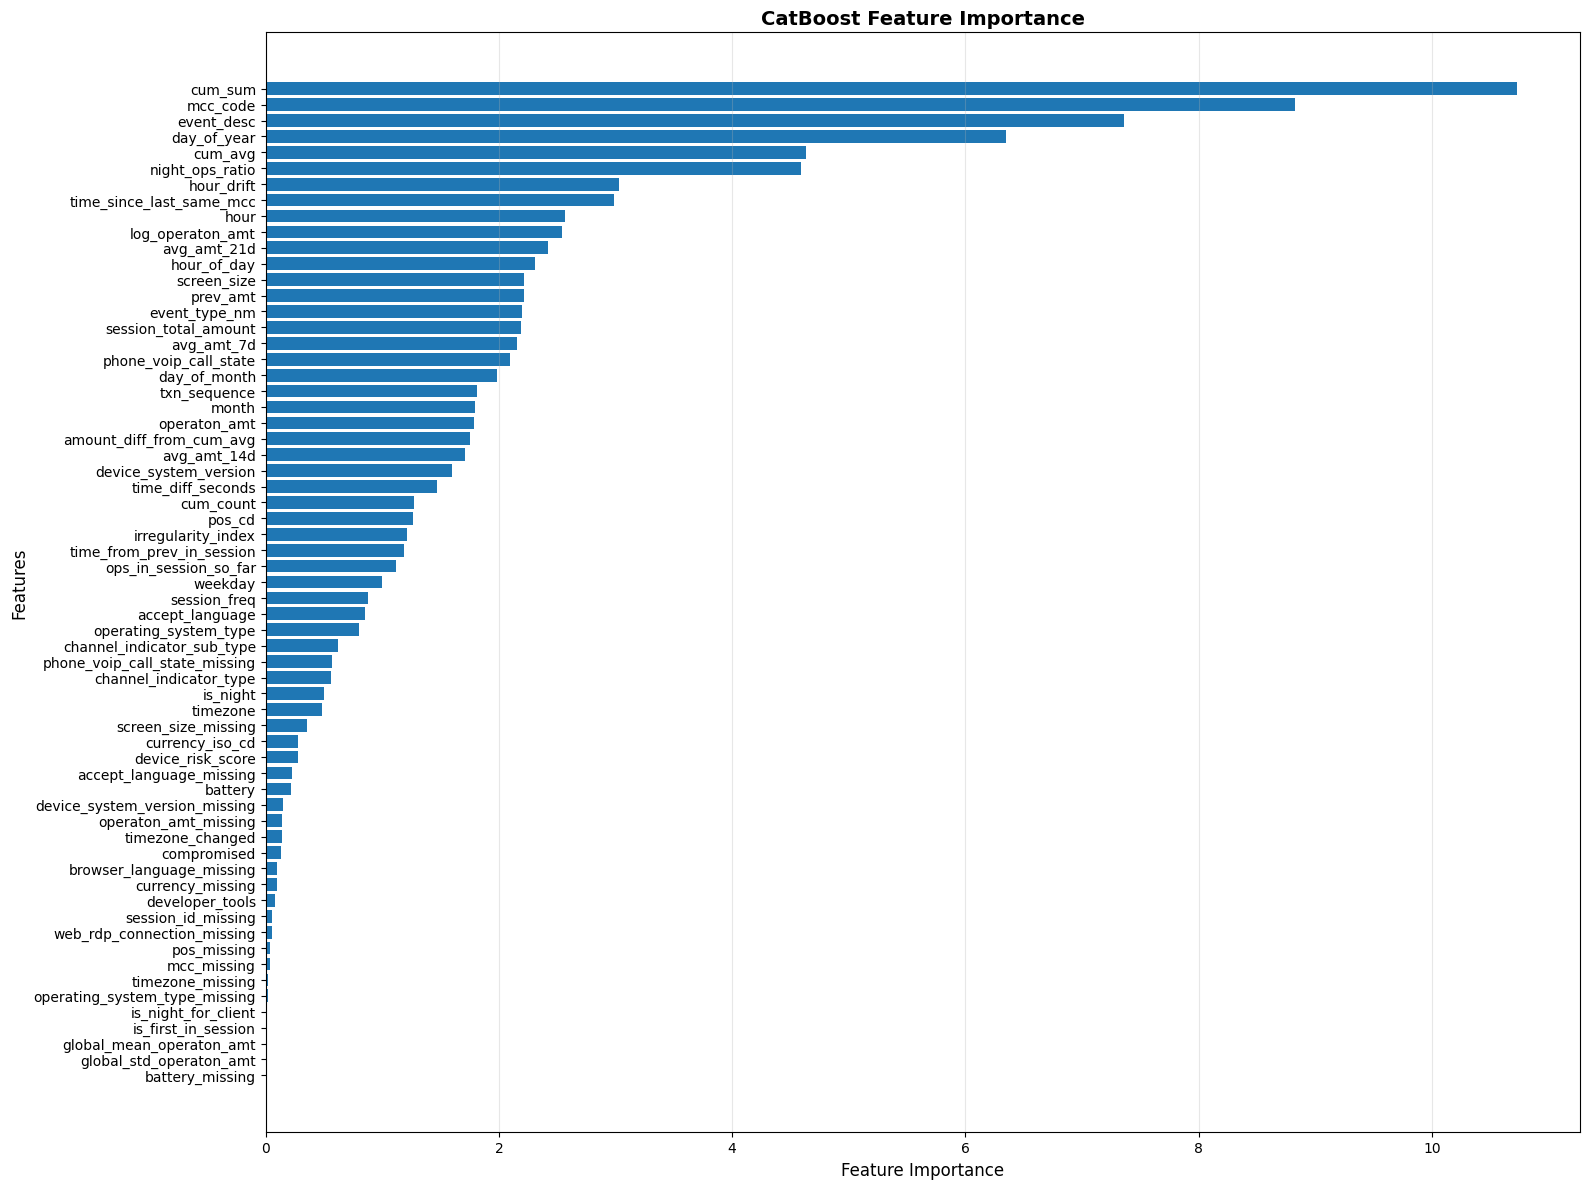

In [ ]:
# Получаем важность признаков из обученной модели
feature_importance = model.get_feature_importance()
feature_names = X_val.columns.tolist()  # или X_train.columns

importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': feature_importance
}).sort_values('importance', ascending=True)

plt.figure(figsize=(16, 12))
plt.barh(importance_df['feature'], importance_df['importance'])
plt.xlabel('Feature Importance', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.title('CatBoost Feature Importance', fontsize=14, fontweight='bold')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## Финальное обучение на полном датасете

In [ ]:
# Объединяем train и val
X_full = pd.concat([X_train, X_val], axis=0, ignore_index=True)
y_full = np.concatenate([y_train, y_val])

print(f"Полный датасет: {X_full.shape}, target distribution: {np.bincount(y_full)}")

# Создаем Pool для полного датасета
full_pool = Pool(X_full, y_full, cat_features=cat_features)

# Обучаем финальную модель
with mlflow.start_run(run_name="final_model_training_full_data"):
    mlflow.log_param("training_type", "full_dataset")
    mlflow.log_param("train_val_rows", len(X_full))

    print("\nОбучение финальной модели на полном датасете...")
    final_model = CatBoostClassifier(**best_params)

    # Обучаем на полном датасете без validation
    final_params = best_params.copy()
    final_params['iterations'] = 4000  # Больше итераций для финального обучения
    final_params['verbose'] = 100

    final_model = CatBoostClassifier(**final_params)
    final_model.fit(full_pool, verbose=100)

    # Логгируем финальную модель
    train_pred = final_model.predict(X_full)
    from sklearn.metrics import roc_auc_score, average_precision_score

    train_auc = roc_auc_score(y_full, final_model.predict_proba(X_full)[:, 1])
    train_ap = average_precision_score(y_full, final_model.predict_proba(X_full)[:, 1])

    mlflow.log_metric("final_train_auc", train_auc)
    mlflow.log_metric("final_train_ap", train_ap)

    print(f"\nФинальная модель на полном датасете:")
    print(f"  AUC-ROC: {train_auc:.4f}")
    print(f"  AP (PR-AUC): {train_ap:.4f}")

    # Логгируем финальную модель
    mlflow.catboost.log_model(final_model, "catboost_final_model")

    # Логгируем лучшие параметры используемые для финального обучения
    for key, val in final_params.items():
        mlflow.log_param(f"final_param_{key}", val)

Полный датасет: (87514, 63), target distribution: [36076 51438]

Обучение финальной модели на полном датасете...
0:	learn: 0.7627488	total: 73.7ms	remaining: 4m 54s
100:	learn: 0.8263111	total: 7.08s	remaining: 4m 33s
200:	learn: 0.8391707	total: 14s	remaining: 4m 25s
300:	learn: 0.8477188	total: 20.7s	remaining: 4m 14s
400:	learn: 0.8555696	total: 27.7s	remaining: 4m 8s
500:	learn: 0.8613880	total: 36.1s	remaining: 4m 12s
600:	learn: 0.8658846	total: 43.3s	remaining: 4m 5s
700:	learn: 0.8697849	total: 49.9s	remaining: 3m 54s
800:	learn: 0.8733786	total: 57.1s	remaining: 3m 47s
900:	learn: 0.8767111	total: 1m 3s	remaining: 3m 38s
1000:	learn: 0.8798220	total: 1m 10s	remaining: 3m 31s
1100:	learn: 0.8825678	total: 1m 17s	remaining: 3m 23s
1200:	learn: 0.8854343	total: 1m 24s	remaining: 3m 16s
1300:	learn: 0.8881827	total: 1m 31s	remaining: 3m 8s
1400:	learn: 0.8905098	total: 1m 38s	remaining: 3m 1s
1500:	learn: 0.8928710	total: 1m 44s	remaining: 2m 54s
1600:	learn: 0.8951721	total: 1m 5

2026/03/23 10:30:41 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



Финальная модель на полном датасете:
  AUC-ROC: 0.9372
  AP (PR-AUC): 0.9546


## Submission

In [ ]:
# Загружаем sample_submit для понимания формата
print("Загрузка sample_submit.csv...")
sample_submit = pd.read_csv(os.path.join(DATA_PATH, "sample_submit.csv"))
print(f"Sample submit shape: {sample_submit.shape}")
print(f"Sample submit columns: {sample_submit.columns.tolist()}")
print(f"Sample submit head:\n{sample_submit.head()}")

# Подготавливаем тестовые данные с MLFlow логгированием
with mlflow.start_run(run_name="test_preparation"):
    print("\n=== Подготовка test данных ===")

    test_df, original_event_ids = prepare_data(
        pretrain_path=os.path.join(DATA_PATH, "pretest.parquet"),
        main_path=os.path.join(DATA_PATH, "test.parquet"),
        target_path=None,
        temp_dir=os.path.join(DRIVE_PATH, "temp_processing_test"),
        is_train=False,
        batch_size=5000
    )

    print(f"\nTest shape: {test_df.shape}")
    print(f"Original event_ids count: {len(original_event_ids)}")

Загрузка sample_submit.csv...
Sample submit shape: (633683, 2)
Sample submit columns: ['event_id', 'predict']
Sample submit head:
          event_id   predict
0  125854726334416 -0.984226
1  125949211749418 -1.141220
2  124437385134670 -0.869487
3  124394437682654 -0.869487
4  123973531121838 -1.039899

=== Подготовка test данных ===
Загрузка pretrain данных...
Pretrain shape: (14202075, 23)
Предобработка pretrain...
Pretrain после preprocessing: (14202075, 45)

Загрузка основных данных...
Найдено файлов: 1

Обработка данных в батчах...


Processing files:   0%|          | 0/1 [00:00<?, ?it/s]


--- Файл 1/1: test.parquet ---
Загружено строк: 633683
Basic preprocessing текущего файла...
После preprocessing: (633683, 45)
Фильтрация pretrain...
Pretrain отфильтрован: 13800490 строк
Pretrain shape: (13800490, 45), Current file shape: (633683, 45)
Computing cumulative features...


Processing files: 100%|██████████| 1/1 [00:48<00:00, 48.95s/it]


Батч сохранен: ./gdrive/MyDrive/antifrod/temp_processing_test/batch_0.parquet

Объединение батчей с диска...


Loading batches: 100%|██████████| 1/1 [00:00<00:00,  2.24it/s]


Итого строк: 646088

Вычисление глобальных фич...
Финальный shape: (646088, 82)

Количество признаков: 78

Подготовка test завершена

Test shape: (646088, 82)
Original event_ids count: 633683


In [ ]:
# Предсказания на test
with mlflow.start_run(run_name="prediction"):
    # Предобработка
    test_df = test_df.with_columns([
        # Создаем новую колонку event_date
        (pl.col('event_dttm').cast(pl.Datetime).cast(pl.Int64) // 1_000_000_000).alias('event_date')
    ]).drop('event_dttm')

    # Выбираем признаки
    X_test = test_df.select(X_val.columns).to_pandas()

    # Преобразуем категориальные признаки в int (CatBoost не принимает float для cat_features)
    for col in cat_features:
        if col in X_test.columns:
          try:
            X_test[col] = X_test[col].fillna(-1).astype(int)
          except:
            pass

    print(f"X_test shape: {X_test.shape}")

    # Логгируем информацию о test
    mlflow.log_param("test_n_rows", len(X_test))

    # Делаем предсказания
    print("\nПредсказание на test данных...")
    predictions = model.predict_proba(X_test)[:, 1]  # Вероятности класса 1

    # Логгируем статистики предсказаний
    mlflow.log_metric("predictions_mean", predictions.mean())
    mlflow.log_metric("predictions_std", predictions.std())
    mlflow.log_metric("predictions_min", predictions.min())
    mlflow.log_metric("predictions_max", predictions.max())

    print(f"Predictions stats: mean={predictions.mean():.4f}, std={predictions.std():.4f}")

X_test shape: (646088, 63)

Предсказание на test данных...
Predictions stats: mean=0.5710, std=0.2234


In [ ]:
# Создаём submit с предсказаниями
with mlflow.start_run(run_name="submission"):
    print("Формирование сабмита...")

    # Получаем event_id из test_df (используем select для корректного извлечения)
    event_ids = test_df.select('event_id').to_pandas()['event_id']

    submit_raw = pd.DataFrame({
        'event_id': event_ids,
        'predict': predictions.astype(np.float32)
    })

    print(f"\nSubmit raw shape: {submit_raw.shape}")
    print(f"Уникальных event_id в предсказаниях: {submit_raw['event_id'].nunique()}")

    # Проверка на дубликаты
    if submit_raw['event_id'].duplicated().any():
        print(f"Найдены дубликаты event_id, удаляем...")
        submit_raw = submit_raw.drop_duplicates(subset=['event_id'], keep='first')
        print(f"После удаления дубликатов: {len(submit_raw)}")

    # Проверка пропущенных event_id
    missing_ids = set(original_event_ids) - set(submit_raw['event_id'])
    if missing_ids:
        print(f"Пропущено {len(missing_ids)} event_id")
        mlflow.log_metric("missing_event_ids", len(missing_ids))
    else:
        print(f"Все event_id найдены")

    # Восстанавливаем исходный порядок event_id
    print("Восстановление исходного порядка...")
    submission = pd.DataFrame({'event_id': original_event_ids})
    submission = submission.merge(submit_raw, on='event_id', how='left')

    # Заполняем пропуски (если есть) средним значением
    submission['predict'] = submission['predict'].fillna(submission['predict'].mean())

    print(f"\nFinal submission shape: {submission.shape}")
    print(f"Submission head:\n{submission.head()}")
    print(f"\nPredictions statistics:")
    print(submission['predict'].describe())

    # Сохраняем
    submit_path = os.path.join(".", "submit.csv")
    submission.to_csv(submit_path, index=False)
    print(f"\nСохранено в: {submit_path}")

    # Логгируем в MLFlow
    mlflow.log_param("submission_n_rows", len(submission))
    mlflow.log_metric("submission_predict_mean", submission['predict'].mean())
    mlflow.log_metric("submission_predict_std", submission['predict'].std())

    # Проверяем соответствие формату sample_submit
    print(f"\nПроверка:")
    submit_check = pd.read_csv(submit_path)
    print(f"Колонки совпадают: {set(submit_check.columns) == set(sample_submit.columns)}")
    print(f"Количество строк: {len(submit_check)} (ожидалось: {len(sample_submit)})")
    print(f"Предсказания в диапазоне [0, 1]: {submit_check['predict'].between(0, 1).all()}")

    # Логгируем артефакт
    mlflow.log_artifact(submit_path)
    print("\nСабмит создан")

Формирование сабмита...

Submit raw shape: (646088, 2)
Уникальных event_id в предсказаниях: 633683
Найдены дубликаты event_id, удаляем...
После удаления дубликатов: 633683
Все event_id найдены
Восстановление исходного порядка...

Final submission shape: (633683, 2)
Submission head:
          event_id   predict
0  123707242230467  0.696014
1  123234793229123  0.583160
2  125837545055907  0.601321
3  126456020999239  0.644456
4  125090221587312  0.165117

Predictions statistics:
count    633683.000000
mean          0.569230
std           0.222541
min           0.002094
25%           0.403295
50%           0.591755
75%           0.745318
max           0.998556
Name: predict, dtype: float64

Сохранено в: ./submit.csv

Проверка:
Колонки совпадают: True
Количество строк: 633683 (ожидалось: 633683)
Предсказания в диапазоне [0, 1]: True

Сабмит создан


In [ ]:
shutil.copy(submit_path, DATA_PATH)

'./gdrive/MyDrive/antifrod/data/submit.csv'

In [ ]:
!ls ./gdrive/MyDrive/antifrod/data -la

total 395753
-rw------- 1 root root 338850719 Mar 10 09:23 pretest.parquet
drwx------ 2 root root      4096 Mar  5 16:20 pretrain
-rw------- 1 root root  21904984 Mar  3 14:17 sample_submit.csv
-rw------- 1 root root  16784394 Mar 23 10:51 submit.csv
-rw------- 1 root root  17195864 Mar  4 06:21 test.parquet
drwx------ 2 root root      4096 Mar  5 16:20 train
-rw------- 1 root root   1157397 Mar  3 14:16 train_labels.parquet
-rw------- 1 root root   7972781 Mar 23 05:12 train_processed.parquet
-rw------- 1 root root   1374696 Mar 23 05:12 val_processed.parquet


# Transformer

In [6]:
!pip install -q torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118

In [23]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import LinearLR, CosineAnnealingLR, SequentialLR
import math

## Data Preparation for Transformer

In [8]:
# 1. Загружаем pretrain (полная история без меток)
print("\n1. Загрузка pretrain данных (история транзакций)...")
pretrain_path = os.path.join(DATA_PATH, "pretrain")
if os.path.isdir(pretrain_path):
    pretrain_files = [os.path.join(pretrain_path, f) for f in os.listdir(pretrain_path) if f.endswith('.parquet')]
    pretrain_dfs = [pl.read_parquet(f) for f in tqdm(pretrain_files, desc="Reading pretrain")]
    pretrain_full = pl.concat(pretrain_dfs)
    del pretrain_dfs
else:
    pretrain_full = pl.read_parquet(pretrain_path)

print(f"Pretrain shape: {pretrain_full.shape}")
print(f"Pretrain customers: {pretrain_full['customer_id'].n_unique()}")

# 2. Загружаем train (размеченные транзакции)
print("\n2. Загрузка train данных (размеченные транзакции)...")
train_path = os.path.join(DATA_PATH, "train")
if os.path.isdir(train_path):
    train_files = [os.path.join(train_path, f) for f in os.listdir(train_path) if f.endswith('.parquet')]
    train_dfs = [pl.read_parquet(f) for f in tqdm(train_files, desc="Reading train")]
    train_full = pl.concat(train_dfs)
    del train_dfs
else:
    train_full = pl.read_parquet(train_path)

print(f"Train shape: {train_full.shape}")
print(f"Train customers: {train_full['customer_id'].n_unique()}")

# 3. Загружаем метки
print("\n3. Загрузка меток...")
train_labels = pl.read_parquet(os.path.join(DATA_PATH, "train_labels.parquet"))
print(f"Labels shape: {train_labels.shape}")

# 4. Добавляем метки к train
print("\n4. Объединение train с метками...")
train_full = train_full.join(train_labels, on=["customer_id", "event_id"], how="left")
print(f"Train с метками: {train_full.shape}")

# Проверяем распределение меток
if 'target' in train_full.columns:
    fraud_count = train_full['target'].sum()
    fraud_rate = train_full['target'].mean()
    print(f"Fraud rate: {fraud_rate:.4%} ({fraud_count} из {len(train_full)})")


1. Загрузка pretrain данных (история транзакций)...


Reading pretrain: 100%|██████████| 3/3 [00:31<00:00, 10.63s/it]


Pretrain shape: (90939957, 23)
Pretrain customers: 100000

2. Загрузка train данных (размеченные транзакции)...


Reading train: 100%|██████████| 3/3 [00:50<00:00, 16.84s/it]


Train shape: (85677840, 23)
Train customers: 100000

3. Загрузка меток...
Labels shape: (87514, 3)

4. Объединение train с метками...
Train с метками: (85677840, 24)
Fraud rate: 58.7769% (51438 из 85677840)


In [9]:
# 5. Объединяем pretrain + train для полной истории
print("\n5. Объединение pretrain + train для полной истории...")
# Добавляем колонку target в pretrain (все None, так как нет меток)
target_type = train_full['target'].dtype
pretrain_full = pretrain_full.with_columns(pl.lit(None, dtype=target_type).alias("target"))

other_columns = [col for col in pretrain_full.columns if col != 'target']

for col in other_columns:
    if col in pretrain_full.columns and col in train_full.columns:
        # Check if column types differ
        pretrain_type = pretrain_full[col].dtype
        train_type = train_full[col].dtype

        if pretrain_type != train_type:
            # Determine common type
            if isinstance(pretrain_type, pl.Int32) and isinstance(train_type, pl.Int64):
                common_type = pl.Int64
                if col in pretrain_full.columns:
                    pretrain_full = pretrain_full.with_columns(pl.col(col).cast(common_type))
            elif isinstance(pretrain_type, pl.Int64) and isinstance(train_type, pl.Int32):
                common_type = pl.Int64
                if col in train_full.columns:
                    train_full = train_full.with_columns(pl.col(col).cast(common_type))
            elif isinstance(pretrain_type, pl.Float32) and isinstance(train_type, pl.Float64):
                common_type = pl.Float64
                if col in pretrain_full.columns:
                    pretrain_full = pretrain_full.with_columns(pl.col(col).cast(common_type))
            elif isinstance(pretrain_type, pl.Float64) and isinstance(train_type, pl.Float32):
                common_type = pl.Float64
                if col in train_full.columns:
                    train_full = train_full.with_columns(pl.col(col).cast(common_type))
            else:
                # For other types, try to use the type from train_full
                print(f"Converting column '{col}' from {pretrain_type} to {train_type}")
                if col in pretrain_full.columns:
                    pretrain_full = pretrain_full.with_columns(pl.col(col).cast(train_type))

# Объединяем
full_history = pl.concat([pretrain_full, train_full])
full_history = full_history.sort(["customer_id", "event_dttm"])

print(f"Полная история: {full_history.shape}")
print(f"Уникальных клиентов: {full_history['customer_id'].n_unique()}")
print(f"Временной диапазон: {full_history['event_dttm'].min()} - {full_history['event_dttm'].max()}")

# 6. Разделяем на train/val по времени (последние 4 недели - val)
print("\n6. Разделение на train/val по времени...")

# Преобразуем event_dttm в datetime тип (если это строка)
if full_history["event_dttm"].dtype == pl.Utf8:
    print("Преобразование event_dttm в datetime...")
    full_history = full_history.with_columns(
        pl.col("event_dttm").str.strptime(pl.Datetime, "%Y-%m-%d %H:%M:%S").alias("event_dttm")
    )

# Получаем max_date как datetime объект
max_date_str = full_history.filter(pl.col("target").is_not_null())["event_dttm"].max()
max_date = datetime.strptime(str(max_date_str), "%Y-%m-%d %H:%M:%S")
split_date = max_date - timedelta(weeks=4)

print(f"Max date: {max_date}")
print(f"Split date: {split_date}")

# Train: все размеченные транзакции до split_date
train_labeled = full_history.filter(
    (pl.col("target").is_not_null()) &
    (pl.col("event_dttm") < pl.lit(split_date))
)

# Val: все размеченные транзакции после split_date
val_labeled = full_history.filter(
    (pl.col("target").is_not_null()) &
    (pl.col("event_dttm") >= pl.lit(split_date))
)

print(f"\nTrain labeled: {train_labeled.shape}")
print(f"Val labeled: {val_labeled.shape}")

if 'target' in train_labeled.columns:
    train_fraud_rate = train_labeled['target'].mean()
    val_fraud_rate = val_labeled['target'].mean()
    print(f"Train fraud rate: {train_fraud_rate:.4%} ({train_labeled['target'].sum()} из {len(train_labeled)})")
    print(f"Val fraud rate: {val_fraud_rate:.4%} ({val_labeled['target'].sum()} из {len(val_labeled)})")

print(f"✓ Полная история: {len(full_history):,} транзакций")
print(f"✓ Train размеченных: {len(train_labeled):,} транзакций")
print(f"✓ Val размеченных: {len(val_labeled):,} транзакций")
print(f"✓ Уникальных клиентов: {full_history['customer_id'].n_unique():,}")


5. Объединение pretrain + train для полной истории...
Полная история: (176617797, 24)
Уникальных клиентов: 100000
Временной диапазон: 2023-10-01 00:00:11 - 2025-05-31 23:59:59

6. Разделение на train/val по времени...
Преобразование event_dttm в datetime...
Max date: 2025-05-31 23:55:33
Split date: 2025-05-03 23:55:33

Train labeled: (74992, 24)
Val labeled: (12522, 24)
Train fraud rate: 59.8437% (44878 из 74992)
Val fraud rate: 52.3878% (6560 из 12522)
✓ Полная история: 176,617,797 транзакций
✓ Train размеченных: 74,992 транзакций
✓ Val размеченных: 12,522 транзакций
✓ Уникальных клиентов: 100,000


In [10]:
def basic_preprocessing(df: pl.LazyFrame) -> pl.LazyFrame:
    """
    Универсальная предобработка:
    - парсинг даты
    - временные признаки
    - флаги пропусков + заполнение для всех ключевых колонок
    - логарифм суммы
    - приведение типов для консистентности
    """
    schema = df.collect_schema()
    columns = schema.names()

    # Дата и время
    if "event_dttm" in columns:
        event_dttm_type = schema["event_dttm"]

        # Парсим только если это строка
        if event_dttm_type == pl.Utf8 or event_dttm_type == pl.String:
            df = df.with_columns(
                pl.col("event_dttm").str.strptime(pl.Datetime, format="%Y-%m-%d %H:%M:%S").alias("event_dttm")
            )
        # Если уже datetime, просто используем как есть

        df = df.with_columns([
            pl.col("event_dttm").dt.hour().alias("hour"),
            pl.col("event_dttm").dt.weekday().alias("weekday"),
            pl.col("event_dttm").dt.day().alias("day_of_month"),
            pl.col("event_dttm").dt.month().alias("month"),
            pl.col("event_dttm").dt.ordinal_day().alias("day_of_year"),
        ])

    # ---------- operaton_amt ----------
    if "operaton_amt" in columns:
        df = df.with_columns([
            pl.col("operaton_amt").is_null().alias("operaton_amt_missing"),
            pl.col("operaton_amt").fill_null(0.0).alias("operaton_amt"),
        ])
        df = df.with_columns(
            pl.col("operaton_amt").log1p().alias("log_operaton_amt")
        )

    # ---------- currency_iso_cd ----------
    if "currency_iso_cd" in columns:
        df = df.with_columns([
            pl.col("currency_iso_cd").is_null().alias("currency_missing"),
            pl.col("currency_iso_cd").fill_null(-1).cast(pl.Int64).alias("currency_iso_cd"),
        ])

    # ---------- mcc_code ----------
    if "mcc_code" in columns:
        df = df.with_columns([
            pl.col("mcc_code").is_null().alias("mcc_missing"),
            pl.col("mcc_code").cast(pl.String).fill_null("-1").cast(pl.Int64).alias("mcc_code"),
        ])

    # ---------- pos_cd ----------
    if "pos_cd" in columns:
        df = df.with_columns([
            pl.col("pos_cd").is_null().alias("pos_missing"),
            pl.col("pos_cd").fill_null(-1).cast(pl.Int64).alias("pos_cd"),
        ])

    # ---------- accept_language ----------
    if "accept_language" in columns:
        df = df.with_columns([
            pl.col("accept_language").is_null().alias("accept_language_missing"),
            pl.col("accept_language").fill_null("unknown").alias("accept_language"),
        ])

    # ---------- browser_language ----------
    if "browser_language" in columns:
        df = df.with_columns([
            pl.col("browser_language").is_null().alias("browser_language_missing"),
            pl.col("browser_language")
              .fill_null("unknown")
              .str.replace_all("not available", "unknown")
              .alias("browser_language")
        ])

    # ---------- timezone ----------
    if "timezone" in columns:
        df = df.with_columns([
            pl.col("timezone").is_null().alias("timezone_missing"),
            pl.col("timezone").fill_null(-1).cast(pl.Int64).alias("timezone"),
        ])

    # ---------- battery ----------
    if "battery" in columns:
        df = df.with_columns([
            pl.col("battery").is_null().alias("battery_missing"),
            pl.when(
                # Сначала обрабатываем специальные строки
                pl.col("battery").is_null() |
                (pl.col("battery") == "not available") |
                (pl.col("battery") == "NaN")
            )
            .then(pl.lit(-1))
            .otherwise(
                # Для остальных пытаемся извлечь цифры
                pl.col("battery")
                  .str.extract(r"(\d+)")
                  .cast(pl.Int64)
            )
            .alias("battery")
        ])

    if "device_system_version" in columns:
        df = df.with_columns([
            pl.col("device_system_version").is_null().alias("device_system_version_missing"),
            pl.col("device_system_version")
              .fill_null("unknown")
              .str.replace_all("not available", "unknown")
              .cast(pl.String)
              .alias("device_system_version")
        ])

    if "screen_size" in columns:
      df = df.with_columns([
          pl.col("screen_size").is_null().alias("screen_size_missing"),
          pl.col("screen_size")
            .fill_null("unknown")
            .str.replace_all("not available", "unknown")
            .cast(pl.String)
            .alias("screen_size")
      ])

    # ---------- Другие колонки ----------
    optional_cols = [
        "session_id", "operating_system_type",
        "developer_tools", "phone_voip_call_state",
        "web_rdp_connection", "compromised"
    ]
    for col in optional_cols:
        if col in columns:
            dtype = schema[col]

            # Для числовых колонок
            if dtype in (pl.Int64, pl.Float64, pl.Int32, pl.Float32, pl.UInt32, pl.UInt64):
                fill_val = 0
                df = df.with_columns(pl.col(col).cast(pl.Int64))
            else:
                # Для строковых - пытаемся привести к Int64
                fill_val = 0
                df = df.with_columns(
                    pl.col(col).cast(pl.String).fill_null("0").cast(pl.Int64).alias(col)
                )

            df = df.with_columns([
                pl.col(col).is_null().alias(f"{col}_missing"),
                pl.col(col).fill_null(fill_val).alias(col),
            ])

    # ФИНАЛЬНОЕ ПРИВЕДЕНИЕ ТИПОВ
    id_cols = ["customer_id", "event_id", "session_id", "event_type_nm", "event_desc",
               "channel_indicator_type", "channel_indicator_sub_type", "currency_iso_cd",
               "mcc_code", "pos_cd", "timezone", "operating_system_type",
               "phone_voip_call_state", "web_rdp_connection", "compromised"]

    schema_cols = df.collect_schema().names()
    for col in id_cols:
        if col in schema_cols:
            df = df.with_columns(pl.col(col).cast(pl.Int64))

    return df

In [11]:
def compute_global_features(df: pl.DataFrame) -> pl.DataFrame:
    """Вычисление глобальных признаков для всего датасета."""
    df = df.with_columns(pl.lit(df.height).alias("global_total_transactions"))
    df = df.with_columns(pl.lit(df["customer_id"].n_unique()).alias("global_unique_customers"))

    if "mcc_code" in df.columns:
        df = df.with_columns(pl.lit(df["mcc_code"].n_unique()).alias("global_unique_mcc"))

    if "event_type_nm" in df.columns:
        df = df.with_columns(pl.lit(df["event_type_nm"].n_unique()).alias("global_unique_event_types"))

    if "operaton_amt" in df.columns:
        global_mean_amt = df["operaton_amt"].mean()
        df = df.with_columns(pl.lit(global_mean_amt).alias("global_mean_operaton_amt"))
        global_std_amt = df["operaton_amt"].std()
        df = df.with_columns(pl.lit(global_std_amt).alias("global_std_operaton_amt"))

    return df

In [12]:
def prepare_transformer_features(full_history_df):
    """Подготовка признаков: basic preprocessing + агрегаты (без кумулятивных фичей)."""
    import gc

    print("\n" + "=" * 80)
    print("ПОДГОТОВКА ПРИЗНАКОВ")
    print("=" * 80)

    print("\n1. Basic preprocessing...")
    df = basic_preprocessing(full_history_df.lazy()).collect()
    print(f"Shape: {df.shape}, Memory: {df.estimated_size('mb'):.2f} MB")

    del full_history_df
    gc.collect()

    print("\n2. Глобальные агрегаты...")
    df = compute_global_features(df)

    print("\n3. Агрегатные фичи по клиенту...")
    customer_stats = df.group_by("customer_id").agg([
        pl.col("operaton_amt").count().alias("customer_total_txns"),
        pl.col("operaton_amt").mean().alias("customer_avg_amt"),
        pl.col("operaton_amt").std().alias("customer_std_amt"),
        pl.col("operaton_amt").min().alias("customer_min_amt"),
        pl.col("operaton_amt").max().alias("customer_max_amt"),
        pl.col("operaton_amt").median().alias("customer_median_amt"),
        pl.col("hour").mode().first().alias("customer_favorite_hour"),
        pl.col("weekday").mode().first().alias("customer_favorite_weekday"),
        pl.col("mcc_code").n_unique().alias("customer_unique_mcc"),
        pl.col("event_type_nm").n_unique().alias("customer_unique_event_types"),
        (pl.col("event_dttm").max() - pl.col("event_dttm").min()).dt.total_days().alias("customer_activity_days"),
    ])

    df = df.join(customer_stats, on="customer_id", how="left")
    print(f"После join: {df.shape}")

    del customer_stats
    gc.collect()

    print("\n4. Производные фичи...")
    df = df.with_columns([
        (pl.col("customer_total_txns") / (pl.col("customer_activity_days") * 24 + 1)).alias("customer_txns_per_hour"),
        (pl.col("customer_std_amt") / (pl.col("customer_avg_amt") + 1e-6)).alias("customer_amt_cv"),
        ((pl.col("operaton_amt") - pl.col("customer_avg_amt")) / (pl.col("customer_std_amt") + 1e-6)).alias("amt_zscore"),
        (df["event_dttm"].max() - pl.col("event_dttm")).dt.total_hours().alias("hours_since_txn"),
    ])

    print(f"\nФинальный shape: {df.shape}")
    print(f"Memory: {df.estimated_size('mb'):.2f} MB")
    print("=" * 80)

    return df

print("\nПрименение preprocessing к полной истории...")
full_history_processed = prepare_transformer_features(full_history)

del full_history
import gc
gc.collect()
print("Исходные данные удалены из памяти")


Применение preprocessing к полной истории...

ПОДГОТОВКА ПРИЗНАКОВ

1. Basic preprocessing...
Shape: (176617797, 46), Memory: 34050.13 MB

2. Глобальные агрегаты...

3. Агрегатные фичи по клиенту...
После join: (176617797, 63)

4. Производные фичи...

Финальный shape: (176617797, 67)
Memory: 55294.10 MB
Исходные данные удалены из памяти


In [13]:
categorical_cols = [
    'event_type_nm', 'event_desc', 'channel_indicator_type',
    'channel_indicator_sub_type', 'currency_iso_cd', 'mcc_code', 'pos_cd',
    'accept_language', 'timezone', 'operating_system_type',
    'battery', 'device_system_version', 'screen_size',
    'developer_tools', 'phone_voip_call_state', 'compromised',
]

numerical_cols = [
    'operaton_amt', 'log_operaton_amt',
    'hour', 'weekday', 'day_of_month', 'month', 'day_of_year',
    'hours_since_txn',
    'global_mean_operaton_amt', 'global_std_operaton_amt',
    'customer_total_txns', 'customer_avg_amt', 'customer_std_amt',
    'customer_min_amt', 'customer_max_amt', 'customer_median_amt',
    'customer_favorite_hour', 'customer_favorite_weekday',
    'customer_unique_mcc', 'customer_unique_event_types',
    'customer_activity_days', 'customer_txns_per_hour',
    'customer_amt_cv', 'amt_zscore',
]

categorical_cols = [col for col in categorical_cols if col in full_history_processed.columns]
numerical_cols = [col for col in numerical_cols if col in full_history_processed.columns]

print(f"\nКатегориальных: {len(categorical_cols)}")
print(f"Числовых: {len(numerical_cols)}")
print(f"Всего: {len(categorical_cols) + len(numerical_cols)}")

print("\nВычисление cardinality...")
categorical_cardinalities = {}
for col in tqdm(categorical_cols, desc="Cardinalities"):
    unique_count = full_history_processed[col].n_unique()
    categorical_cardinalities[col] = unique_count + 1

print(f"\nТоп-10 cardinalities:")
for col, card in sorted(categorical_cardinalities.items(), key=lambda x: x[1], reverse=True)[:10]:
    print(f"  {col}: {card:,}")

print("\n" + "=" * 80)


Категориальных: 16
Числовых: 24
Всего: 40

Вычисление cardinality...


Cardinalities: 100%|██████████| 16/16 [00:09<00:00,  1.71it/s]


Топ-10 cardinalities:
  timezone: 8,289
  screen_size: 2,392
  accept_language: 1,428
  event_desc: 157
  device_system_version: 129
  battery: 102
  pos_cd: 31
  currency_iso_cd: 27
  channel_indicator_sub_type: 22
  mcc_code: 22



In [14]:
print(f"До: {full_history_processed.shape}, {full_history_processed.estimated_size('mb'):.2f} MB")

required_cols = ['customer_id', 'event_id', 'event_dttm', 'target'] + categorical_cols + numerical_cols
required_cols = list(set(required_cols))
required_cols = [col for col in required_cols if col in full_history_processed.columns]

print(f"Оставляем {len(required_cols)} из {len(full_history_processed.columns)} колонок")

full_history_processed = full_history_processed.select(required_cols)

print(f"После: {full_history_processed.shape}, {full_history_processed.estimated_size('mb'):.2f} MB")

import gc
gc.collect()

До: (176617797, 67), 55294.10 MB
Оставляем 44 из 67 колонок
После: (176617797, 44), 48346.06 MB


0

## FraudTransformer Architecture

In [15]:
class RotaryPositionalEmbedding(nn.Module):
    """
    Rotary Positional Embedding (RoPE) для последовательности транзакций.
    Используется для кодирования позиции транзакции в истории клиента.
    """
    def __init__(self, dim, max_seq_len=512):
        super().__init__()
        self.dim = dim
        inv_freq = 1.0 / (10000 ** (torch.arange(0, dim, 2).float() / dim))
        self.register_buffer('inv_freq', inv_freq)

    def forward(self, seq_len, device):
        # Создаем позиционные эмбеддинги для последовательности
        t = torch.arange(seq_len, device=device, dtype=self.inv_freq.dtype)
        freqs = torch.einsum('i,j->ij', t, self.inv_freq)
        emb = torch.cat((freqs, freqs), dim=-1)
        return emb  # [seq_len, dim]


class SinusoidalTimeEncoder(nn.Module):
    """
    Sinusoidal time encoder для интервалов между транзакциями.
    Кодирует временные интервалы в непрерывное представление.
    """
    def __init__(self, d_model, max_time=24*30):  # до месяца в часах
        super().__init__()
        self.d_model = d_model
        self.max_time = max_time

        # Learnable scaling для адаптации к данным
        self.scale = nn.Parameter(torch.ones(1))

    def forward(self, time_diffs):
        """
        Args:
            time_diffs: [batch, seq_len] — часы между транзакциями
        Returns:
            pe: [batch, seq_len, d_model] — временные эмбеддинги
        """
        batch_size, seq_len = time_diffs.shape

        # Нормализуем временные интервалы
        time_norm = torch.clamp(time_diffs / self.max_time, 0, 1)
        time_norm = time_norm.unsqueeze(-1) * self.scale

        # Sinusoidal encoding
        div_term = torch.exp(torch.arange(0, self.d_model, 2, device=time_diffs.device) *
                            -(math.log(10000.0) / self.d_model))

        pe = torch.zeros(batch_size, seq_len, self.d_model, device=time_diffs.device)
        pe[:, :, 0::2] = torch.sin(time_norm * div_term)
        pe[:, :, 1::2] = torch.cos(time_norm * div_term)

        return pe

In [24]:
class FraudTransformer(nn.Module):
    def __init__(self,
                 categorical_cols,
                 categorical_cardinalities,
                 numerical_cols,
                 quantized_cardinalities,
                 aggregate_dim,
                 embedding_dim=128,
                 num_heads=8,
                 num_layers=6,
                 max_seq_len=50,
                 dropout=0.1):

        super().__init__()

        self.embedding_dim = embedding_dim
        self.max_seq_len = max_seq_len
        self.categorical_cols = categorical_cols
        self.numerical_cols = numerical_cols

        # 1. Эмбеддинги для категориальных признаков
        self.cat_embeddings = nn.ModuleDict({
            col: nn.Embedding(categorical_cardinalities[col], embedding_dim // 4, padding_idx=0)
            for col in categorical_cols
        })

        # 2. Эмбеддинги для квантизованных числовых признаков
        seq_numerical_cols = [col for col in numerical_cols
                              if not (col.startswith('customer_') or col.startswith('mcc_'))]
        self.num_embeddings = nn.ModuleDict({
            col: nn.Embedding(quantized_cardinalities[col], embedding_dim // len(seq_numerical_cols) if seq_numerical_cols else 1, padding_idx=0)
            for col in seq_numerical_cols if col in quantized_cardinalities
        })

        # 3. Временной энкодер
        self.time_encoder = SinusoidalTimeEncoder(embedding_dim // 4)

        # 4. Проекция объединенных признаков
        total_cat_dim = len(categorical_cols) * (embedding_dim // 4)
        total_num_dim = len(seq_numerical_cols) * (embedding_dim // len(seq_numerical_cols) if seq_numerical_cols else 0)
        total_time_dim = embedding_dim // 4
        total_input_dim = total_cat_dim + total_num_dim + total_time_dim

        self.input_projection = nn.Linear(total_input_dim, embedding_dim)

        # 5. Проекция агрегатных фичей с нормализацией
        self.aggregate_norm = nn.LayerNorm(aggregate_dim)
        self.aggregate_projection = nn.Sequential(
            nn.Linear(aggregate_dim, embedding_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(embedding_dim, embedding_dim)
        )

        # 6. Positional encoder
        self.rotary_pos_emb = RotaryPositionalEmbedding(embedding_dim)

        # 7. Transformer Decoder
        decoder_layer = nn.TransformerDecoderLayer(
            d_model=embedding_dim,
            nhead=num_heads,
            dim_feedforward=embedding_dim * 4,
            dropout=dropout,
            activation='gelu',
            batch_first=True,
            norm_first=True
        )
        self.transformer = nn.TransformerDecoder(decoder_layer, num_layers=num_layers)

        self.register_buffer("causal_mask",
                            torch.triu(torch.ones(max_seq_len, max_seq_len) * float('-inf'), diagonal=1))

        # 8. LayerNorm
        self.norm = nn.LayerNorm(embedding_dim)

        # 9. Classification head
        self.classifier = nn.Sequential(
            nn.Linear(embedding_dim * 2, embedding_dim),
            nn.GELU(),
            nn.Linear(embedding_dim, embedding_dim // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(embedding_dim // 2, 1)
        )

        self.dropout = nn.Dropout(dropout)
        self.apply(self._init_weights)

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            torch.nn.init.xavier_uniform_(module.weight)
            if module.bias is not None:
                torch.nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            torch.nn.init.normal_(module.weight, mean=0, std=0.02)

    def forward(self, cat_features, num_features, time_diffs, aggregate_features, seq_lens):
        batch_size = time_diffs.shape[0]
        seq_len = time_diffs.shape[1]
        device = time_diffs.device

        # 1. Категориальные эмбеддинги
        cat_tokens = []
        for col in self.categorical_cols:
            if col in cat_features:
                token = self.cat_embeddings[col](cat_features[col])
                cat_tokens.append(token)

        cat_combined = torch.cat(cat_tokens, dim=-1) if cat_tokens else torch.zeros(
            batch_size, seq_len, 0, device=device
        )

        # 2. Числовые эмбеддинги (квантизованные)
        num_tokens = []
        for col in self.num_embeddings.keys():
            if col in num_features:
                token = self.num_embeddings[col](num_features[col])
                num_tokens.append(token)

        num_combined = torch.cat(num_tokens, dim=-1) if num_tokens else torch.zeros(
            batch_size, seq_len, 0, device=device
        )

        # 3. Временные эмбеддинги
        time_emb = self.time_encoder(time_diffs)

        # 4. Объединяем
        combined = torch.cat([cat_combined, num_combined, time_emb], dim=-1)

        # 5. Проекция
        x = self.input_projection(combined)
        x = self.dropout(x)

        # 6. Positional encoding
        pos_emb = self.rotary_pos_emb(seq_len, device)
        x = x + pos_emb.unsqueeze(0)

        # 7. Causal mask
        causal_mask = self.causal_mask[:seq_len, :seq_len]

        # 8. Transformer
        transformer_out = self.transformer(
            tgt=x,
            memory=x,
            tgt_mask=causal_mask,
            memory_mask=causal_mask
        )

        # 9. Последний токен
        last_token_indices = torch.tensor(seq_lens, device=device) - 1
        last_tokens = transformer_out[torch.arange(batch_size, device=device), last_token_indices, :]

        # 10. LayerNorm
        last_tokens = self.norm(last_tokens)

        # 11. Агрегатные фичи с нормализацией
        aggregate_features = self.aggregate_norm(aggregate_features)
        aggregate_emb = self.aggregate_projection(aggregate_features)

        # 12. Объединяем
        combined_features = torch.cat([last_tokens, aggregate_emb], dim=-1)

        # 13. Classification
        logits = self.classifier(combined_features)

        return logits.squeeze(-1)

## Training Setup

In [17]:
import numpy as np
from sklearn.preprocessing import KBinsDiscretizer

seq_numerical_cols = [col for col in numerical_cols
                      if not (col.startswith('customer_') or col.startswith('mcc_'))]

print(f"Числовых признаков для квантизации: {len(seq_numerical_cols)}")

quantizers = {}
quantized_cardinalities = {}

for col in tqdm(seq_numerical_cols, desc="Квантизация"):
    values = full_history_processed[col].to_numpy().reshape(-1, 1)
    values = np.nan_to_num(values, nan=0.0, posinf=1e6, neginf=-1e6)

    quantizer = KBinsDiscretizer(n_bins=TRANSFORMER_N_BINS, encode='ordinal',
                                 strategy='quantile', subsample=None)
    quantizer.fit(values)

    quantizers[col] = quantizer
    quantized_cardinalities[col] = TRANSFORMER_N_BINS + 1

print(f"Квантизаторы созданы для {len(quantizers)} признаков")
print(f"Количество бинов: {TRANSFORMER_N_BINS}")

Числовых признаков для квантизации: 11


Квантизация:   0%|          | 0/11 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_discretization.py:306: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 0 are removed. Consider decreasing the number of bins.
  warnings.warn(
Квантизация:   9%|▉         | 1/11 [00:06<01:04,  6.41s/it]/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_discretization.py:306: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 0 are removed. Consider decreasing the number of bins.
  warnings.warn(
Квантизация:  18%|█▊        | 2/11 [00:11<00:51,  5.70s/it]/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_discretization.py:306: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 0 are removed. Consider decreasing the number of bins.
  warnings.warn(
Квантизация:  27%|██▋       | 3/11 [00:13<00:33,  4.14s/it]/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_discretization.py:306:

Квантизаторы созданы для 11 признаков
Количество бинов: 50


In [18]:
class FraudSequenceDatasetMemoryEfficient(Dataset):
    """Датасет для FraudTransformer - работает прямо с данными в памяти."""

    def __init__(self, full_history_df, labeled_df, categorical_cols, numerical_cols,
                 categorical_cardinalities, quantizers, max_seq_len=TRANSFORMER_MAX_SEQ_LEN):
        self.full_history_df = full_history_df
        self.labeled_df = labeled_df
        self.categorical_cols = categorical_cols
        self.numerical_cols = numerical_cols
        self.categorical_cardinalities = categorical_cardinalities
        self.quantizers = quantizers
        self.max_seq_len = max_seq_len

        available_cols = set(full_history_df.columns)
        self.agg_cols = sorted([col for col in numerical_cols
                               if (col.startswith('customer_') or col.startswith('mcc_'))
                               and col in available_cols])
        print(f"Агрегатных признаков: {len(self.agg_cols)}")

        print("Создание индексов...")
        self.customer_indices = {}
        for i, row in tqdm(enumerate(full_history_df.iter_rows(named=True))):
            cid = row['customer_id']
            if cid not in self.customer_indices:
                self.customer_indices[cid] = []
            self.customer_indices[cid].append(i)

    def __len__(self):
        return len(self.labeled_df)

    def __getitem__(self, idx):
        row_dict = self.labeled_df[idx].to_dict()

        customer_id = row_dict['customer_id']
        if hasattr(customer_id, 'item'):
            customer_id = customer_id.item()

        event_dttm = row_dict['event_dttm']
        if hasattr(event_dttm, 'item'):
            event_dttm = event_dttm.item()

        target = row_dict['target']
        if hasattr(target, 'item'):
            target = target.item()

        customer_txn_indices = self.customer_indices.get(customer_id, [])

        valid_indices = []
        for i in customer_txn_indices:
            row = self.full_history_df[i].to_dict()
            txn_dttm = row['event_dttm']
            if hasattr(txn_dttm, 'item'):
                txn_dttm = txn_dttm.item()
            if txn_dttm <= event_dttm:
                valid_indices.append(i)

        seq_indices = valid_indices[-self.max_seq_len:]
        seq_len = len(seq_indices)

        sequence = []
        for i in seq_indices:
            row_dict = self.full_history_df[i].to_dict()
            clean_row = {}
            for k, v in row_dict.items():
                while hasattr(v, 'item'):
                    try:
                        v = v.item()
                    except:
                        break
                if hasattr(v, 'to_python'):
                    try:
                        v = v.to_python()
                    except:
                        pass
                clean_row[k] = v
            sequence.append(clean_row)

        cat_features = self._extract_categorical(sequence)
        num_features = self._extract_numerical(sequence)
        time_diffs = self._extract_time_diffs(sequence)

        if len(sequence) > 0 and len(self.agg_cols) > 0:
            agg_values = []
            for col in self.agg_cols:
                val = sequence[-1].get(col, 0.0)
                val = float(val) if val is not None else 0.0
                if np.isnan(val) or np.isinf(val):
                    val = 0.0
                agg_values.append(val)
        else:
            agg_values = [0.0] * max(1, len(self.agg_cols))
        agg_tensor = torch.tensor(agg_values, dtype=torch.float32)

        label_value = float(target) if target is not None else 0.0

        return {
            'cat_features': cat_features,
            'num_features': num_features,
            'time_diffs': time_diffs,
            'aggregate_features': agg_tensor,
            'label': torch.tensor(label_value, dtype=torch.float32),
            'seq_len': seq_len
        }

    def _extract_categorical(self, seq):
        result = {}
        for col in self.categorical_cols:
            values = []
            for row in seq:
                val = row.get(col, -1)
                if hasattr(val, 'item'):
                    val = val.item()
                if val is None or (isinstance(val, float) and np.isnan(val)):
                    val = 0
                elif isinstance(val, str):
                    val = abs(hash(val)) % (self.categorical_cardinalities[col] - 1) + 1
                else:
                    try:
                        val = int(val)
                    except (ValueError, TypeError):
                        val = 0
                values.append(val)
            values = np.array(values, dtype=np.int64)

            if len(values) < self.max_seq_len:
                pad_len = self.max_seq_len - len(values)
                values = np.concatenate([np.zeros(pad_len, dtype=np.int64), values])

            values = np.clip(values, 0, self.categorical_cardinalities[col] - 1)
            result[col] = torch.tensor(values, dtype=torch.long)

        return result

    def _extract_numerical(self, seq):
        result = {}
        for col in self.numerical_cols:
            if col.startswith('customer_') or col.startswith('mcc_'):
                continue

            values = []
            for row in seq:
                val = row.get(col, 0.0)
                if hasattr(val, 'item'):
                    val = val.item()
                try:
                    val = float(val)
                    if np.isnan(val) or np.isinf(val):
                        val = 0.0
                except (ValueError, TypeError):
                    val = 0.0
                values.append(val)
            values = np.array(values, dtype=np.float32)

            if col in self.quantizers:
                values_reshaped = values.reshape(-1, 1)
                values_reshaped = np.nan_to_num(values_reshaped, nan=0.0, posinf=1e6, neginf=-1e6)
                quantized = self.quantizers[col].transform(values_reshaped).flatten()
                values = quantized.astype(np.int64)

            if len(values) < self.max_seq_len:
                pad_len = self.max_seq_len - len(values)
                values = np.concatenate([np.zeros(pad_len, dtype=values.dtype), values])

            result[col] = torch.tensor(values, dtype=torch.long if col in self.quantizers else torch.float32)

        return result

    def _extract_time_diffs(self, seq):
        if len(seq) == 0:
            return torch.zeros(self.max_seq_len, dtype=torch.float32)

        time_diffs = np.zeros(len(seq), dtype=np.float32)
        for i in range(1, len(seq)):
            t1 = seq[i-1]['event_dttm']
            t2 = seq[i]['event_dttm']

            while hasattr(t1, 'item'):
                try:
                    t1 = t1.item()
                except:
                    break
            while hasattr(t2, 'item'):
                try:
                    t2 = t2.item()
                except:
                    break

            try:
                diff = t2 - t1
                if hasattr(diff, 'total_seconds'):
                    time_diffs[i] = diff.total_seconds() / 3600.0
                else:
                    time_diffs[i] = 0.0
            except (AttributeError, TypeError):
                time_diffs[i] = 0.0

        time_diffs = np.nan_to_num(time_diffs, nan=0.0, posinf=1e6, neginf=-1e6)

        if len(time_diffs) < self.max_seq_len:
            pad_len = self.max_seq_len - len(time_diffs)
            time_diffs = np.concatenate([np.zeros(pad_len, dtype=np.float32), time_diffs])

        return torch.tensor(time_diffs, dtype=torch.float32)

In [19]:
train_dataset = FraudSequenceDatasetMemoryEfficient(
    full_history_df=full_history_processed,
    labeled_df=train_labeled,
    categorical_cols=categorical_cols,
    numerical_cols=numerical_cols,
    categorical_cardinalities=categorical_cardinalities,
    quantizers=quantizers,
    max_seq_len=TRANSFORMER_MAX_SEQ_LEN
)
print(f"Train dataset: {len(train_dataset):,} последовательностей")

val_dataset = FraudSequenceDatasetMemoryEfficient(
    full_history_df=full_history_processed,
    labeled_df=val_labeled,
    categorical_cols=categorical_cols,
    numerical_cols=numerical_cols,
    categorical_cardinalities=categorical_cardinalities,
    quantizers=quantizers,
    max_seq_len=TRANSFORMER_MAX_SEQ_LEN
)
print(f"Val dataset: {len(val_dataset):,} последовательностей")

Агрегатных признаков: 13
Создание индексов...


176617797it [07:30, 392088.21it/s]


Train dataset: 74,992 последовательностей
Агрегатных признаков: 13
Создание индексов...


176617797it [07:30, 392327.23it/s]

Val dataset: 12,522 последовательностей


In [20]:
def collate_fn(batch):
    """Custom collate function для DataLoader."""
    cat_features = {}
    num_features = {}

    for col in batch[0]['cat_features'].keys():
        cat_features[col] = torch.stack([item['cat_features'][col] for item in batch])

    for col in batch[0]['num_features'].keys():
        num_features[col] = torch.stack([item['num_features'][col] for item in batch])

    time_diffs = torch.stack([item['time_diffs'] for item in batch])
    aggregate_features = torch.stack([item['aggregate_features'] for item in batch])
    labels = torch.stack([item['label'] for item in batch])
    seq_lens = [item['seq_len'] for item in batch]

    return {
        'cat_features': cat_features,
        'num_features': num_features,
        'time_diffs': time_diffs,
        'aggregate_features': aggregate_features,
        'labels': labels,
        'seq_lens': seq_lens
    }

In [21]:
train_loader = DataLoader(
    train_dataset,
    batch_size=TRANSFORMER_BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_fn,
    num_workers=TRANSFORMER_NUM_WORKERS,
    pin_memory=TRANSFORMER_PIN_MEMORY
)

val_loader = DataLoader(
    val_dataset,
    batch_size=TRANSFORMER_VAL_BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_fn,
    num_workers=TRANSFORMER_NUM_WORKERS,
    pin_memory=TRANSFORMER_PIN_MEMORY
)

print(f"\nTrain batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")

sample_batch = next(iter(train_loader))
print(f"\nБатч: Cat={len(sample_batch['cat_features'])}, Num={len(sample_batch['num_features'])}")
print(f"Time diffs: {sample_batch['time_diffs'].shape}")
print(f"Aggregate: {sample_batch['aggregate_features'].shape}")
print(f"Seq lens: min={min(sample_batch['seq_lens'])}, max={max(sample_batch['seq_lens'])}")


Train batches: 586
Val batches: 98

Батч: Cat=16, Num=11
Time diffs: torch.Size([128, 100])
Aggregate: torch.Size([128, 13])
Seq lens: min=100, max=100


## Training Loop

In [22]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

aggregate_dim = len(train_dataset.agg_cols) if hasattr(train_dataset, 'agg_cols') else 1
if aggregate_dim == 0:
    aggregate_dim = 1
print(f"Aggregate features dimension: {aggregate_dim}")

model = FraudTransformer(
    categorical_cols=categorical_cols,
    categorical_cardinalities=categorical_cardinalities,
    numerical_cols=numerical_cols,
    quantized_cardinalities=quantized_cardinalities,
    aggregate_dim=aggregate_dim,
    embedding_dim=TRANSFORMER_EMBEDDING_DIM,
    num_heads=TRANSFORMER_NUM_HEADS,
    num_layers=TRANSFORMER_NUM_LAYERS,
    max_seq_len=TRANSFORMER_MAX_SEQ_LEN,
    dropout=TRANSFORMER_DROPOUT
).to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)


print(f"Параметров: {total_params:,} (обучаемых: {trainable_params:,})")
print(f"Размер: {total_params * 4 / 1024 / 1024:.2f} MB")
print(f"{'='*80}")

Device: cuda
Aggregate features dimension: 13
Параметров: 2,143,543 (обучаемых: 2,143,543)
Размер: 8.18 MB


In [25]:
train_labels_array = train_labeled['target'].to_numpy()
num_positives = train_labels_array.sum()
num_negatives = len(train_labels_array) - num_positives

pos_weight_value = num_negatives / num_positives
pos_weight = torch.tensor([pos_weight_value]).to(device)

print(f"Положительных: {num_positives:,} | Отрицательных: {num_negatives:,}")
print(f"Pos weight: {pos_weight_value:.2f}")
print(f"{'='*80}")

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = AdamW(model.parameters(), lr=TRANSFORMER_LEARNING_RATE,
                  weight_decay=TRANSFORMER_WEIGHT_DECAY)

warmup_epochs = 3 # количество эпох для warmup
warmup_scheduler = LinearLR(optimizer, start_factor=0.01, end_factor=1.0, total_iters=warmup_epochs)
cosine_scheduler = CosineAnnealingLR(optimizer, T_max=20, eta_min=1e-6)

# Комбинированный шедулер
scheduler = SequentialLR(
  optimizer,
  schedulers=[warmup_scheduler, cosine_scheduler],
  milestones=[warmup_epochs]
)

print(f"\nOptimizer: AdamW (lr={TRANSFORMER_LEARNING_RATE}, wd={TRANSFORMER_WEIGHT_DECAY})")
print(f"Scheduler: CosineAnnealingLR (T_max={TRANSFORMER_SCHEDULER_T_MAX})")

Положительных: 44,878 | Отрицательных: 30,114
Pos weight: 0.67

Optimizer: AdamW (lr=3e-05, wd=0.01)
Scheduler: CosineAnnealingLR (T_max=20)


In [26]:
def train_epoch(model, train_loader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    all_preds = []
    all_labels = []

    pbar = tqdm(train_loader, desc="Training")
    for batch_idx, batch in enumerate(pbar):
        cat_features = {k: v.to(device) for k, v in batch['cat_features'].items()}
        num_features = {k: v.to(device) for k, v in batch['num_features'].items()}
        time_diffs = batch['time_diffs'].to(device)
        aggregate_features = batch['aggregate_features'].to(device)
        labels = batch['labels'].to(device)
        seq_lens = batch['seq_lens']

        if torch.isnan(aggregate_features).any() or torch.isinf(aggregate_features).any():
            aggregate_features = torch.nan_to_num(aggregate_features, nan=0.0, posinf=1e6, neginf=-1e6)

        optimizer.zero_grad()
        logits = model(cat_features, num_features, time_diffs, aggregate_features, seq_lens)

        if torch.isnan(logits).any() or torch.isinf(logits).any():
            continue

        loss = criterion(logits, labels)

        if torch.isnan(loss) or torch.isinf(loss):
            continue

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=TRANSFORMER_GRAD_CLIP_NORM)
        optimizer.step()

        total_loss += loss.item()
        preds = torch.sigmoid(logits).detach().cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.cpu().numpy())

        pbar.set_postfix({'loss': loss.item()})

    avg_loss = total_loss / len(train_loader)

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)

    if np.isnan(all_preds).any() or np.isinf(all_preds).any():
        all_preds = np.nan_to_num(all_preds, nan=0.5, posinf=1.0, neginf=0.0)

    auc = roc_auc_score(all_labels, all_preds)
    ap = average_precision_score(all_labels, all_preds)

    return avg_loss, auc, ap


def validate(model, val_loader, criterion, device):
    model.eval()
    total_loss = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in tqdm(val_loader, desc="Validation"):
            cat_features = {k: v.to(device) for k, v in batch['cat_features'].items()}
            num_features = {k: v.to(device) for k, v in batch['num_features'].items()}
            time_diffs = batch['time_diffs'].to(device)
            aggregate_features = batch['aggregate_features'].to(device)
            labels = batch['labels'].to(device)
            seq_lens = batch['seq_lens']

            if torch.isnan(aggregate_features).any() or torch.isinf(aggregate_features).any():
                aggregate_features = torch.nan_to_num(aggregate_features, nan=0.0, posinf=1e6, neginf=-1e6)

            logits = model(cat_features, num_features, time_diffs, aggregate_features, seq_lens)

            if torch.isnan(logits).any() or torch.isinf(logits).any():
                continue

            loss = criterion(logits, labels)

            total_loss += loss.item()
            preds = torch.sigmoid(logits).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(val_loader)

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)

    if np.isnan(all_preds).any() or np.isinf(all_preds).any():
        all_preds = np.nan_to_num(all_preds, nan=0.5, posinf=1.0, neginf=0.0)

    auc = roc_auc_score(all_labels, all_preds)
    ap = average_precision_score(all_labels, all_preds)

    return avg_loss, auc, ap

In [ ]:
num_epochs = TRANSFORMER_NUM_EPOCHS
best_val_ap = 0.8569
patience_counter = 0

history = {
    'train_loss': [],
    'train_auc': [],
    'train_ap': [],
    'val_loss': [],
    'val_auc': [],
    'val_ap': [],
    'lr': []
}

print(f"\n{'='*80}")
print("НАЧАЛО ОБУЧЕНИЯ")
print(f"{'='*80}")
print(f"Epochs: {num_epochs} | Patience: {TRANSFORMER_PATIENCE}")
print(f"{'='*80}\n")

with mlflow.start_run(run_name="fraud_transformer_training"):
    mlflow.log_param("model_type", "FraudTransformer")
    mlflow.log_param("embedding_dim", TRANSFORMER_EMBEDDING_DIM)
    mlflow.log_param("num_heads", TRANSFORMER_NUM_HEADS)
    mlflow.log_param("num_layers", TRANSFORMER_NUM_LAYERS)
    mlflow.log_param("max_seq_len", TRANSFORMER_MAX_SEQ_LEN)
    mlflow.log_param("batch_size", TRANSFORMER_BATCH_SIZE)
    mlflow.log_param("learning_rate", TRANSFORMER_LEARNING_RATE)
    mlflow.log_param("num_epochs", num_epochs)

    for epoch in range(num_epochs):
        print(f"\n{'='*80}")
        print(f"EPOCH {epoch + 1}/{num_epochs}")
        print(f"{'='*80}")

        train_loss, train_auc, train_ap = train_epoch(
            model, train_loader, criterion, optimizer, device
        )

        val_loss, val_auc, val_ap = validate(
            model, val_loader, criterion, device
        )

        scheduler.step()
        current_lr = optimizer.param_groups[0]['lr']

        history['train_loss'].append(train_loss)
        history['train_auc'].append(train_auc)
        history['train_ap'].append(train_ap)
        history['val_loss'].append(val_loss)
        history['val_auc'].append(val_auc)
        history['val_ap'].append(val_ap)
        history['lr'].append(current_lr)

        mlflow.log_metric("train_loss", train_loss, step=epoch)
        mlflow.log_metric("train_auc", train_auc, step=epoch)
        mlflow.log_metric("train_ap", train_ap, step=epoch)
        mlflow.log_metric("val_loss", val_loss, step=epoch)
        mlflow.log_metric("val_auc", val_auc, step=epoch)
        mlflow.log_metric("val_ap", val_ap, step=epoch)
        mlflow.log_metric("learning_rate", current_lr, step=epoch)

        print(f"\nTrain: Loss={train_loss:.4f} | AUC={train_auc:.4f} | AP={train_ap:.4f}")
        print(f"Val:   Loss={val_loss:.4f} | AUC={val_auc:.4f} | AP={val_ap:.4f}")
        print(f"LR: {current_lr:.6f}")

        if val_ap > best_val_ap:
            best_val_ap = val_ap
            patience_counter = 0
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_ap': val_ap,
            }, os.path.join(DATA_PATH, 'best_fraud_transformer.pt'))
            print(f"✓ Лучшая модель сохранена! Val AP: {val_ap:.4f}")
        else:
            patience_counter += 1
            print(f"Patience: {patience_counter}/{TRANSFORMER_PATIENCE}")

            if patience_counter >= TRANSFORMER_PATIENCE:
                print("\nEarly stopping!")
                break

    mlflow.log_metric("best_val_ap", best_val_ap)
    print("\n" + "=" * 80)
    print(f"ОБУЧЕНИЕ ЗАВЕРШЕНО! Лучший Val AP: {best_val_ap:.4f}")
    print("=" * 80)


НАЧАЛО ОБУЧЕНИЯ
Epochs: 8 | Patience: 5


EPOCH 1/8


Validation: 100%|██████████| 98/98 [04:59<00:00,  3.06s/it]



Train: Loss=0.5730 | AUC=0.5021 | AP=0.5996
Val:   Loss=0.5794 | AUC=0.5403 | AP=0.5619
LR: 0.000010
Patience: 1/5

EPOCH 2/8


Validation: 100%|██████████| 98/98 [04:59<00:00,  3.05s/it]



Train: Loss=0.5599 | AUC=0.4980 | AP=0.5991
Val:   Loss=0.5721 | AUC=0.5447 | AP=0.5722
LR: 0.000020
Patience: 2/5

EPOCH 3/8


Validation: 100%|██████████| 98/98 [04:58<00:00,  3.04s/it]



Train: Loss=0.5579 | AUC=0.4988 | AP=0.5972
Val:   Loss=0.5710 | AUC=0.5588 | AP=0.5896
LR: 0.000030
Patience: 3/5

EPOCH 4/8


Validation:  42%|████▏     | 41/98 [01:59<02:45,  2.90s/it]

## Training Visualization

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('FraudTransformer Training History', fontsize=16, fontweight='bold', y=1.02)

epochs = range(1, len(history['train_loss']) + 1)

# Loss
ax1 = axes[0, 0]
ax1.plot(epochs, history['train_loss'], 'b-', label='Train', linewidth=2, marker='o', markersize=4)
ax1.plot(epochs, history['val_loss'], 'r-', label='Val', linewidth=2, marker='s', markersize=4)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

# AUC-ROC
ax2 = axes[0, 1]
ax2.plot(epochs, history['train_auc'], 'b-', label='Train', linewidth=2, marker='o', markersize=4)
ax2.plot(epochs, history['val_auc'], 'r-', label='Val', linewidth=2, marker='s', markersize=4)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('AUC-ROC')
ax2.set_title('AUC-ROC')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_ylim([0, 1])

# PR-AUC
ax3 = axes[0, 2]
ax3.plot(epochs, history['train_ap'], 'b-', label='Train', linewidth=2, marker='o', markersize=4)
ax3.plot(epochs, history['val_ap'], 'r-', label='Val', linewidth=2, marker='s', markersize=4)
ax3.axhline(y=best_val_ap, color='g', linestyle='--', label=f'Best: {best_val_ap:.4f}', linewidth=1.5)
ax3.set_xlabel('Epoch')
ax3.set_ylabel('PR-AUC')
ax3.set_title('PR-AUC')
ax3.legend()
ax3.grid(True, alpha=0.3)
ax3.set_ylim([0, 1])

# Learning Rate
ax4 = axes[1, 0]
ax4.plot(epochs, history['lr'], 'g-', linewidth=2, marker='o', markersize=4)
ax4.set_xlabel('Epoch')
ax4.set_ylabel('Learning Rate')
ax4.set_title('Learning Rate')
ax4.set_yscale('log')
ax4.grid(True, alpha=0.3)

# Train-Val Gap
ax5 = axes[1, 1]
train_val_gap_auc = np.array(history['train_auc']) - np.array(history['val_auc'])
train_val_gap_ap = np.array(history['train_ap']) - np.array(history['val_ap'])
ax5.plot(epochs, train_val_gap_auc, 'b-', label='AUC Gap', linewidth=2, marker='o', markersize=4)
ax5.plot(epochs, train_val_gap_ap, 'r-', label='AP Gap', linewidth=2, marker='s', markersize=4)
ax5.axhline(y=0, color='black', linestyle='-', linewidth=1)
ax5.set_xlabel('Epoch')
ax5.set_ylabel('Train - Val')
ax5.set_title('Overfitting Check')
ax5.legend()
ax5.grid(True, alpha=0.3)

# Best Epoch
ax6 = axes[1, 2]
best_epoch = np.argmax(history['val_ap']) + 1
ax6.plot(epochs, history['val_ap'], 'r-', label='Val PR-AUC', linewidth=2, marker='s', markersize=6)
ax6.axvline(x=best_epoch, color='green', linestyle='--', linewidth=2, label=f'Best: {best_epoch}')
ax6.scatter([best_epoch], [best_val_ap], color='green', s=200, zorder=5, marker='*')
ax6.set_xlabel('Epoch')
ax6.set_ylabel('PR-AUC')
ax6.set_title('Best Model')
ax6.legend()
ax6.grid(True, alpha=0.3)
ax6.set_ylim([0, 1])

plt.tight_layout()
plt.savefig(os.path.join(DATA_PATH, 'training_history.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✓ График сохранен: {os.path.join(DATA_PATH, 'training_history.png')}")

## Model Evaluation

In [ ]:
checkpoint = torch.load(os.path.join(DATA_PATH, 'best_fraud_transformer.pt'), weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
print(f"Загружена модель с эпохи {checkpoint['epoch'] + 1}, Val AP: {checkpoint['val_ap']:.4f}")

val_loss, val_auc, val_ap = validate(model, val_loader, criterion, device)

print(f"\nФинальная оценка:")
print(f"Val Loss: {val_loss:.4f} | AUC: {val_auc:.4f} | AP: {val_ap:.4f}")

Загружена лучшая модель с эпохи 2
Val AP: 0.8569


Validation: 100%|██████████| 98/98 [04:48<00:00,  2.95s/it]

Финальная оценка на валидации:
Val Loss: 0.4054
Val AUC-ROC: 0.8386
Val PR-AUC: 0.8569


## Transformer Submission

In [24]:
# Загрузка sample_submit для формата
sample_submit = pd.read_csv(os.path.join(DATA_PATH, "sample_submit.csv"))
print(f"Sample submit: {sample_submit.shape}")
print(sample_submit.head())

Sample submit: (633683, 2)
          event_id   predict
0  125854726334416 -0.984226
1  125949211749418 -1.141220
2  124437385134670 -0.869487
3  124394437682654 -0.869487
4  123973531121838 -1.039899


In [25]:
# Загружаем pretest и test
pretest_path = os.path.join(DATA_PATH, "pretest.parquet")
test_path = os.path.join(DATA_PATH, "test.parquet")

pretest_full = pl.read_parquet(pretest_path)
test_full = pl.read_parquet(test_path)

print(f"Pretest: {pretest_full.shape}")
print(f"Test: {test_full.shape}")

# Сохраняем исходный порядок event_id
original_test_event_ids = test_full['event_id'].to_list()
print(f"Исходных event_id: {len(original_test_event_ids)}")

# Добавляем target=None для pretest
pretest_full = pretest_full.with_columns(pl.lit(None, dtype=pl.Float64).alias("target"))
test_full = test_full.with_columns(pl.lit(None, dtype=pl.Float64).alias("target"))

# Приводим типы к единому формату
for col in pretest_full.columns:
    if col in test_full.columns:
        pretest_type = pretest_full[col].dtype
        test_type = test_full[col].dtype

        if pretest_type != test_type:
            if isinstance(pretest_type, pl.Int32) and isinstance(test_type, pl.Int64):
                pretest_full = pretest_full.with_columns(pl.col(col).cast(pl.Int64))
            elif isinstance(pretest_type, pl.Int64) and isinstance(test_type, pl.Int32):
                test_full = test_full.with_columns(pl.col(col).cast(pl.Int64))

# Объединяем для полной истории
test_history = pl.concat([pretest_full, test_full])
test_history = test_history.sort(["customer_id", "event_dttm"])

print(f"Test history: {test_history.shape}")

# Применяем preprocessing
print("\nPreprocessing...")
test_history = basic_preprocessing(test_history.lazy()).collect()
test_history = compute_global_features(test_history)

# Агрегатные фичи по клиенту
customer_stats = test_history.group_by("customer_id").agg([
    pl.col("operaton_amt").count().alias("customer_total_txns"),
    pl.col("operaton_amt").mean().alias("customer_avg_amt"),
    pl.col("operaton_amt").std().alias("customer_std_amt"),
    pl.col("operaton_amt").min().alias("customer_min_amt"),
    pl.col("operaton_amt").max().alias("customer_max_amt"),
    pl.col("operaton_amt").median().alias("customer_median_amt"),
    pl.col("hour").mode().first().alias("customer_favorite_hour"),
    pl.col("weekday").mode().first().alias("customer_favorite_weekday"),
    pl.col("mcc_code").n_unique().alias("customer_unique_mcc"),
    pl.col("event_type_nm").n_unique().alias("customer_unique_event_types"),
    (pl.col("event_dttm").max() - pl.col("event_dttm").min()).dt.total_days().alias("customer_activity_days"),
])

test_history = test_history.join(customer_stats, on="customer_id", how="left")

# Производные фичи
test_history = test_history.with_columns([
    (pl.col("customer_total_txns") / (pl.col("customer_activity_days") * 24 + 1)).alias("customer_txns_per_hour"),
    (pl.col("customer_std_amt") / (pl.col("customer_avg_amt") + 1e-6)).alias("customer_amt_cv"),
    ((pl.col("operaton_amt") - pl.col("customer_avg_amt")) / (pl.col("customer_std_amt") + 1e-6)).alias("amt_zscore"),
    (test_history["event_dttm"].max() - pl.col("event_dttm")).dt.total_hours().alias("hours_since_txn"),
])

# Оставляем только нужные колонки
required_cols = ['customer_id', 'event_id', 'event_dttm', 'target'] + categorical_cols + numerical_cols
required_cols = list(set(required_cols))
required_cols = [col for col in required_cols if col in test_history.columns]
test_history = test_history.select(required_cols)

print(f"Test history processed: {test_history.shape}")

# Фильтруем только test транзакции
test_labeled = test_history.filter(pl.col("event_id").is_in(original_test_event_ids))
print(f"Test labeled: {test_labeled.shape}")

Pretest: (14202075, 23)
Test: (633683, 23)
Исходных event_id: 633683
Test history: (14835758, 24)

Preprocessing...
Test history processed: (14835758, 44)
Test labeled: (646088, 44)


In [26]:
# Создаем test dataset
test_dataset = FraudSequenceDatasetMemoryEfficient(
    full_history_df=test_history,
    labeled_df=test_labeled,
    categorical_cols=categorical_cols,
    numerical_cols=numerical_cols,
    categorical_cardinalities=categorical_cardinalities,
    quantizers=quantizers,
    max_seq_len=TRANSFORMER_MAX_SEQ_LEN
)

test_loader = DataLoader(
    test_dataset,
    batch_size=TRANSFORMER_VAL_BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_fn,
    num_workers=TRANSFORMER_NUM_WORKERS,
    pin_memory=TRANSFORMER_PIN_MEMORY
)

print(f"Test dataset: {len(test_dataset):,} последовательностей")
print(f"Test batches: {len(test_loader)}")

Агрегатных признаков: 13
Создание индексов...


14835758it [00:39, 373632.34it/s]

Test dataset: 646,088 последовательностей
Test batches: 5048


In [27]:
# Загружаем лучшую модель и делаем предсказания
checkpoint = torch.load(os.path.join(DATA_PATH, 'best_fraud_transformer.pt'), weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
print(f"Загружена модель с эпохи {checkpoint['epoch'] + 1}, Val AP: {checkpoint['val_ap']:.4f}")

model.eval()
all_predictions = []

with torch.no_grad():
    for batch in tqdm(test_loader, desc="Предсказание"):
        cat_features = {k: v.to(device) for k, v in batch['cat_features'].items()}
        num_features = {k: v.to(device) for k, v in batch['num_features'].items()}
        time_diffs = batch['time_diffs'].to(device)
        aggregate_features = batch['aggregate_features'].to(device)
        seq_lens = batch['seq_lens']

        if torch.isnan(aggregate_features).any() or torch.isinf(aggregate_features).any():
            aggregate_features = torch.nan_to_num(aggregate_features, nan=0.0, posinf=1e6, neginf=-1e6)

        logits = model(cat_features, num_features, time_diffs, aggregate_features, seq_lens)
        preds = torch.sigmoid(logits).cpu().numpy()
        all_predictions.extend(preds)

predictions = np.array(all_predictions)
print(f"Предсказания: mean={predictions.mean():.4f}, std={predictions.std():.4f}")

Загружена модель с эпохи 2, Val AP: 0.8569


Предсказание: 100%|██████████| 5048/5048 [43:21<00:00,  1.94it/s]

Предсказания: mean=0.4592, std=0.2527


In [28]:
# Формирование submission файла
with mlflow.start_run(run_name="transformer_submission"):
    event_ids = test_labeled.select('event_id').to_pandas()['event_id']

    submit_raw = pd.DataFrame({
        'event_id': event_ids,
        'predict': predictions.astype(np.float32)
    })

    print(f"\nSubmit raw: {submit_raw.shape}")
    print(f"Уникальных event_id: {submit_raw['event_id'].nunique()}")

    # Проверка дубликатов
    if submit_raw['event_id'].duplicated().any():
        print("Удаление дубликатов...")
        submit_raw = submit_raw.drop_duplicates(subset=['event_id'], keep='first')
        print(f"После удаления: {len(submit_raw)}")

    # Проверка пропущенных event_id
    missing_ids = set(original_test_event_ids) - set(submit_raw['event_id'])
    if missing_ids:
        print(f"⚠️ Пропущено {len(missing_ids)} event_id")
        mlflow.log_metric("missing_event_ids", len(missing_ids))

    # Восстанавливаем исходный порядок
    submission = pd.DataFrame({'event_id': original_test_event_ids})
    submission = submission.merge(submit_raw, on='event_id', how='left')
    submission['predict'] = submission['predict'].fillna(submission['predict'].mean())

    print(f"\nFinal submission: {submission.shape}")
    print(submission.head())
    print(f"\nСтатистика предсказаний:")
    print(submission['predict'].describe())

    # Сохранение
    submit_path = os.path.join(DATA_PATH, "transformer_submit.csv")
    submission.to_csv(submit_path, index=False)
    print(f"\n✓ Сохранено: {submit_path}")

    # Логгирование
    mlflow.log_param("submission_n_rows", len(submission))
    mlflow.log_metric("submission_predict_mean", submission['predict'].mean())
    mlflow.log_metric("submission_predict_std", submission['predict'].std())

    # Проверка формата
    submit_check = pd.read_csv(submit_path)
    print(f"\nПроверка:")
    print(f"  Колонки: {set(submit_check.columns) == set(sample_submit.columns)}")
    print(f"  Строк: {len(submit_check)} (ожидалось: {len(sample_submit)})")
    print(f"  Диапазон [0,1]: {submit_check['predict'].between(0, 1).all()}")

    mlflow.log_artifact(submit_path)


Submit raw: (646088, 2)
Уникальных event_id: 633683
Удаление дубликатов...
После удаления: 633683

Final submission: (633683, 2)
          event_id   predict
0  123707242230467  0.489837
1  123234793229123  0.492289
2  125837545055907  0.538620
3  126456020999239  0.550459
4  125090221587312  0.130486

Статистика предсказаний:
count    633683.000000
mean          0.456184
std           0.251201
min           0.002362
25%           0.246463
50%           0.443362
75%           0.656104
max           0.993959
Name: predict, dtype: float64

✓ Сохранено: ./gdrive/MyDrive/antifrod/data/transformer_submit.csv

Проверка:
  Колонки: True
  Строк: 633683 (ожидалось: 633683)
  Диапазон [0,1]: True
